## US E-Commerce Dataset Analysis 

In [3]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew


# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking
# !pip install tqdm
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return '${:,.0f}'.format(x)

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [4]:
#CONVERT CSV to df

df = pd.read_csv('US_ecommercerecords2020_dataset/US  E-commerce records 2020.csv', encoding='latin1')
df

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,30-12-20,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,30-12-20,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,30-12-20,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,30-12-20,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


# 1) EDA of Dataset: PRE-PROCESSING

In [5]:
df['Region'].value_counts()

Region
West       1095
East        921
Central     778
South       518
Name: count, dtype: int64

In [6]:
#PREPROCESSING HERE


#1) Handling Missing Values
        #none here
    


#2) Categorical Variables Consistent Formats



#3) Standardize Units
df['Unit Price']= df['Sales']/df['Quantity']
#4) Remove Duplicates 

#5) Filter Unrealistic Values

#6) Detect Outliers 



In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

In [8]:
display(
df['Order ID'].nunique(),  
df['Product ID'].nunique(),
df['Customer ID'].nunique(),
df['Row ID'].nunique(),
df['Segment'].unique(),
df['Ship Mode'].unique()

)

1687

1525

693

3312

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

array(['Standard Class', 'First Class', 'Second Class', 'Same Day'],
      dtype=object)

## FEATURE DESCRIPTIONS
- order id = 1687 diff total orders, multiple products can be same order -> each customer assigned ID for EACH ORDER they place  
- product id = 1525 diff products, each product has individual identifier 
    - so thus 1787 duplicate products
- customer id = 693 diff customers, each customer themself has an ID 
- row id = 3312 values, EVERY ROW has different id so like an index
- segment = CUSTOMER TYPE 
- ship mode = first class, standard, etc.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

# 2) EDA of Dataset: Univariate Analysis 


<Axes: >

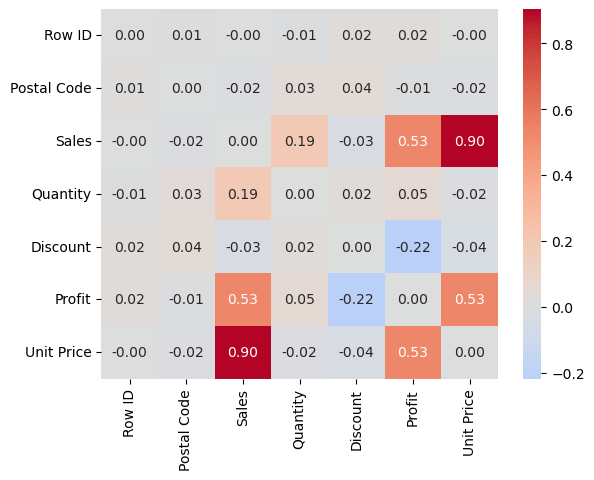

In [10]:
#Heatmap    BIVARIATE HERE
corr = df.corr(numeric_only=True)
np.fill_diagonal(corr.values,0)

sns.heatmap(corr, cmap='coolwarm', annot=True, center=0, fmt='.2f')

In [11]:
#HOW MANY ORDERS PER REGION
df['Region'].value_counts()

Region
West       1095
East        921
Central     778
South       518
Name: count, dtype: int64

In [12]:
#Most ordered products! 
df['Product Name'].value_counts().head(10)

Product Name
Easy-staple paper                                  16
Staples                                            15
Staples in misc. colors                            12
Staple envelope                                    11
Staple remover                                      8
Global Wood Trimmed Manager's Task Chair, Khaki     8
Storex Dura Pro Binders                             8
Strathmore Photo Mount Cards                        7
Sterilite Officeware Hinged File Box                7
Logitech Desktop MK120 Mouse and keyboard Combo     7
Name: count, dtype: int64

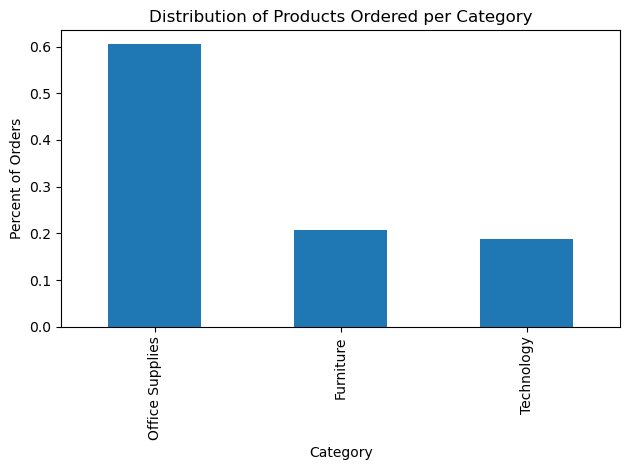

In [13]:
# Dist of categories -> are there more orders for specific category 
cats = df['Category'].value_counts(normalize=True)

cats.plot(kind='bar')
plt.title('Distribution of Products Ordered per Category')
plt.ylabel('Percent of Orders')
plt.tight_layout()
plt.show()

count    3312.000000
mean       60.392382
std       152.194508
min         0.336000
25%         5.430000
50%        15.992000
75%        60.972500
max      3499.990000
Name: Unit Price, dtype: float64

<Axes: xlabel='Unit Price', ylabel='Count'>

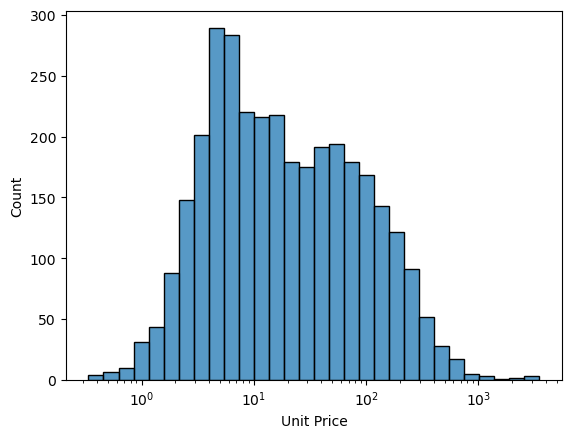

In [14]:
#Average Sales Data -> typical cost of each product 

display(df['Unit Price'].describe())
sns.histplot(df['Unit Price'], bins=30, log_scale=True)

In [15]:
# Histograms, Bar Charts

#box plot, kde, swarm, violin plots

#Identify Distributions, skewed, binomial ex) use log transformation instead

#Summary Statistics mean, med, mode

#Detect Extreme values

# 3) EDA of Dataset: Bivariate Analysis 

In [16]:
#Products per order = cart aka basket size
carts = df.groupby('Order ID')['Product ID'].nunique() #how many items in each order
carts.describe()

count    1687.000000
mean        1.962063
std         1.399791
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: Product ID, dtype: float64

In [17]:
regionorders = df['Region'].value_counts().values
regionorders #west, east, central, south

array([1095,  921,  778,  518])

In [18]:
#Sales by Region
sales4regions= df.groupby('Region')['Sales'].sum()
salebyregion = sales4regions.sort_values(ascending=False).values
display(salebyregion)

print (f'sales per order by region W, E, C, S {salebyregion/regionorders}')

array([250128.3655, 213082.904 , 147098.1282, 122905.8575])

sales per order by region W, E, C, S [228.42773105 231.36037351 189.07214422 237.26999517]


In [19]:
#Profit by Region
sales3regions= df.groupby('Region')['Profit'].sum()
profitregion = sales3regions.sort_values(ascending=False)
display (profitregion)

profit_per_order = (
    df.groupby('Region')['Profit'].sum() /
    df.groupby('Region').size()
).sort_values(ascending=False)
profit_per_order

Region
West       43808.9561
East       33230.5614
South       8848.9079
Central     7550.8442
Name: Profit, dtype: float64

Region
West       40.008179
East       36.080957
South      17.082834
Central     9.705455
dtype: float64

In [20]:
#CORRELATION BETWEEN NUMBER OF ORDERS AND TOTAL PROFIT
orders = df.groupby('Region').size()
profit = df.groupby('Region')['Profit'].sum()

corr = orders.corr(profit)
print(corr)

0.883769687101028


In [21]:
# actually multivariate analysis here   USE THIS TABLE
# MOST ORDERED PRODUCTS BY EACH REGION
top3perregion =df.groupby('Region')['Product Name'].value_counts().groupby(level=0).head(3).reset_index()

top3perregion

,Region,Product Name,count
0,Central,Easy-staple paper,9
1,Central,Acco 6 Outlet Guardian Premium Plus Surge Supp...,4
2,Central,Avery 511,4
3,East,Xerox 191,4
4,East,3M Organizer Strips,3
5,East,Acco Data Flex Cable Posts For Top & Bottom Lo...,3
6,South,Staples,4
7,South,Easy-staple paper,3
8,South,"Gould Plastics 18-Pocket Panel Bin, 34w x 5-1/...",3
9,West,"Lesro Sheffield Collection Coffee Table, End T...",5


In [22]:
#Category vs profit -> which product category makes most money
df.groupby('Category')['Profit'].sum()

Category
Furniture           3018.3913
Office Supplies    39736.6217
Technology         50684.2566
Name: Profit, dtype: float64

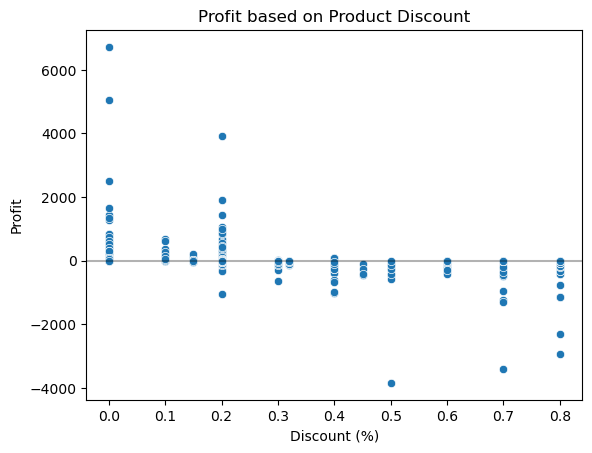

In [23]:
#Discounts vs Profit
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Profit based on Product Discount')
plt.xlabel('Discount (%)')
plt.axhline(0, color='black', alpha=0.3)

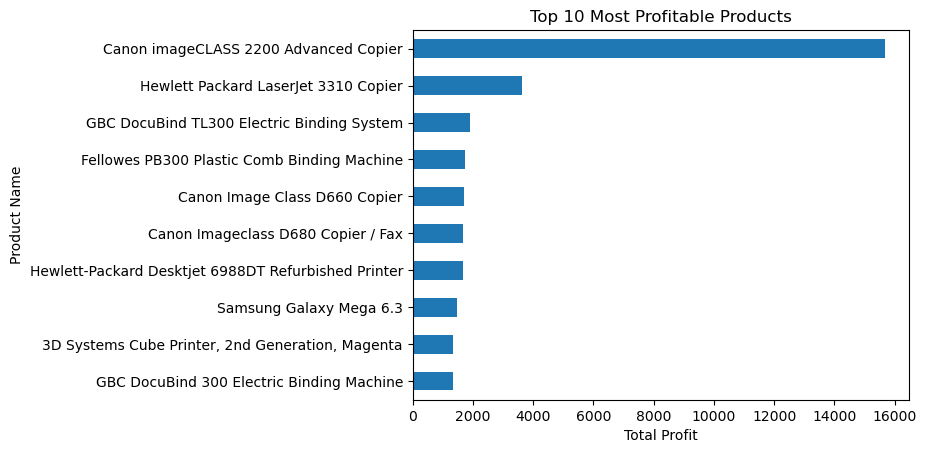

In [24]:
#Best profitable products 
top = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top.plot(kind='barh')
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit")
plt.gca().invert_yaxis()
plt.show()



In [25]:
    #code notes for .str.contains
df[df['Product Name'].str.contains('2200', case=False)]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price
427,23-03-20,8154,CA-2017-140151,First Class,RB-19360,Consumer,United States,Seattle,Washington,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,3499.990
2302,22-10-20,2624,CA-2017-127180,First Class,TA-21385,Home Office,United States,New York City,New York,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888,2799.992
2644,17-11-20,4191,CA-2017-166709,Standard Class,HL-15040,Consumer,United States,Newark,Delaware,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856,3499.990


In [26]:
#Plots - scatter matrix, line, waterfall, area, pair

#Box plot of outcomes by category 

#Correlation matrix, heatmap!


#Crosstab table or grouped means


# 4) Conclusions: Expected or Unexpected
- explained in essay

# 5) Conclusions: Datasets Disqualified  
- explained in essay


# 6) Conclusions: Supervised or Unsupervised analysis   
- explained in essay


<br><br>
---
# 📊 Milestone 4 START Multivariate Analysis, Modeling, Etc.



---


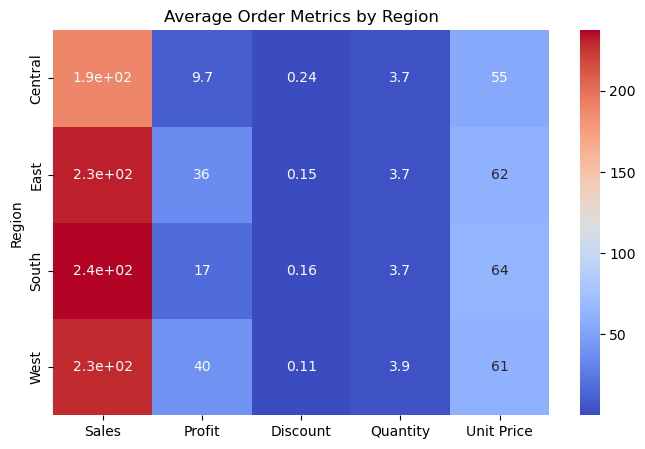

In [27]:
#heatmap with region
region_heat = df.groupby('Region')[
    ['Sales','Profit','Discount','Quantity','Unit Price']
].mean()

plt.figure(figsize=(8,5))
sns.heatmap(region_heat, annot=True, cmap='coolwarm')
plt.title("Average Order Metrics by Region")
plt.show()

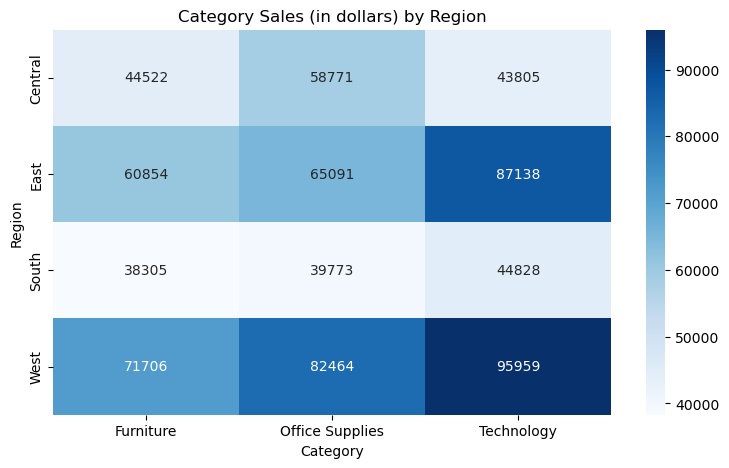

In [28]:
#pivot table to organize heatmap by 
pivot = pd.pivot_table(
    df,
    values='Sales', #numbers we want to track
    index='Region', # GROUPING y-axis 
    columns='Category', #ANOTHER GROUP x-axis
    aggfunc='sum'   #function so total sales
)

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title("Category Sales (in dollars) by Region")
plt.show()

In [29]:
#dataframe organization of total sales, profit, and average discount/quantity BY REGION
df_region = df.groupby('Region').agg(
    orders=('Order ID', 'count'),
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
    avg_discount=('Discount', 'mean'),
    avg_quantity=('Quantity', 'mean')
).reset_index()
df_region

,Region,orders,total_sales,total_profit,avg_discount,avg_quantity
0,Central,778,147098.1282,7550.8442,0.239614,3.701799
1,East,921,213082.9040,33230.5614,0.147774,3.703583
2,South,518,122905.8575,8848.9079,0.155405,3.696911
3,West,1095,250128.3655,43808.9561,0.105205,3.899543


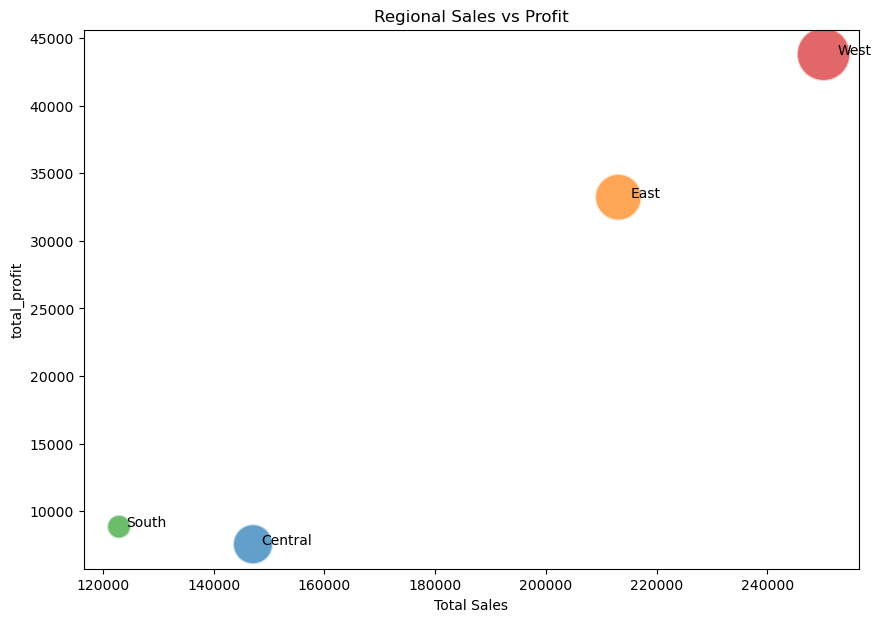

In [30]:
#bubble plot by region

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_region,
    x='total_sales',
    y='total_profit',
    size='orders',
    hue='Region',
    sizes=(300, 1500),
    alpha=0.7
)

for _, row in df_region.iterrows():
    plt.text(
        row['total_sales']*1.01,
        row['total_profit'],
        row['Region'],
        fontsize=10
    )

plt.title("Regional Sales vs Profit")
plt.xlabel("Total Sales")
plt.legend([],[], frameon=False)
plt.show()

In [31]:
#PCA HERE 

#build columns
num_cols = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'Unit Price'
]

cat_cols = ['Region']   

df_pca = df[num_cols + cat_cols].dropna().copy() #cat plus numerical columns

#ONE-HOT ENCODE REGION 
df_encoded = pd.get_dummies(
    df_pca,
    columns=cat_cols,
    drop_first=False
)

#save features as list 
pca_features = df_encoded.columns.tolist()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pd.Series(
    pca.explained_variance_ratio_,
    index=[f'PC{i}' for i in range(1, len(pca_features)+1)]
)

print(explained)

PC1    2.633641e-01
PC2    1.711295e-01
PC3    1.546998e-01
PC4    1.354585e-01
PC5    1.136085e-01
PC6    9.718496e-02
PC7    5.653550e-02
PC8    8.019033e-03
PC9    1.544953e-16
dtype: float64


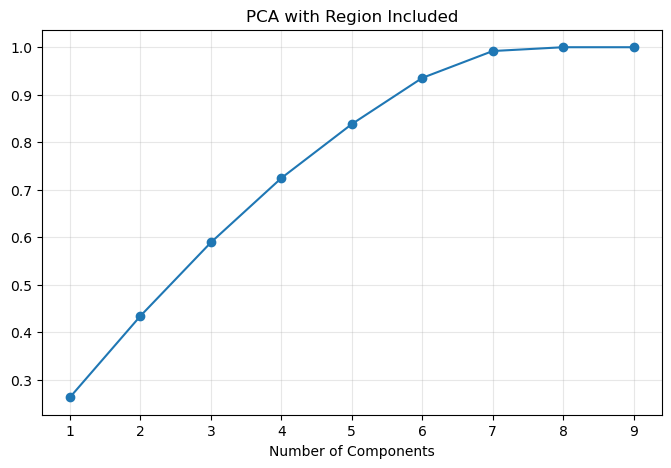

In [32]:
#scree plot
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained)+1),
    explained.cumsum(),
    marker='o'
)

plt.xlabel("Number of Components")
plt.title("PCA with Region Included")
plt.xticks(range(1, len(explained)+1))
plt.grid(alpha=0.3)
plt.show()

In [33]:
#component loadings 
components_df = pd.DataFrame(
    pca.components_,
    columns=pca_features,
    index = [f'PC{i}' for i in range(1, pca.components_.shape[0]+1)]
)
components_df

,Sales,Quantity,Discount,Profit,Unit Price,Region_Central,Region_East,Region_South,Region_West
PC1,6.039727e-01,9.635816e-02,-1.292765e-01,4.952577e-01,5.953358e-01,-0.079229,0.018549,-0.000076,0.053791
PC2,-1.145807e-01,2.816200e-02,-4.202280e-01,1.970982e-02,-1.226536e-01,-0.519899,-0.177139,-0.077886,0.697363
PC3,-5.821405e-02,-8.052502e-02,-2.004657e-01,1.995619e-02,-5.033159e-02,-0.490347,0.783991,-0.002102,-0.303185
PC4,-3.140472e-03,-6.817032e-02,-7.084063e-02,-2.100468e-02,7.826364e-03,-0.264465,-0.265712,0.898986,-0.202734
PC5,1.029811e-01,9.241749e-01,2.593517e-01,-1.368351e-01,-1.101357e-01,-0.163105,0.073109,0.067888,0.024934
PC6,1.384937e-01,-3.153006e-01,7.473300e-01,-2.557155e-01,2.100125e-01,-0.368218,0.063710,-0.000582,0.271595
PC7,-3.037634e-01,-2.150596e-03,3.684096e-01,8.181487e-01,-3.060642e-01,-0.076730,-0.000748,0.036238,0.041878
PC8,7.047210e-01,-1.589726e-01,-3.722888e-04,3.209849e-03,-6.913946e-01,0.004812,-0.004647,-0.002952,0.002368
PC9,-8.049936e-17,2.864552e-16,-9.959726e-17,-1.084167e-16,4.959393e-17,0.494922,0.523074,0.424054,0.549203


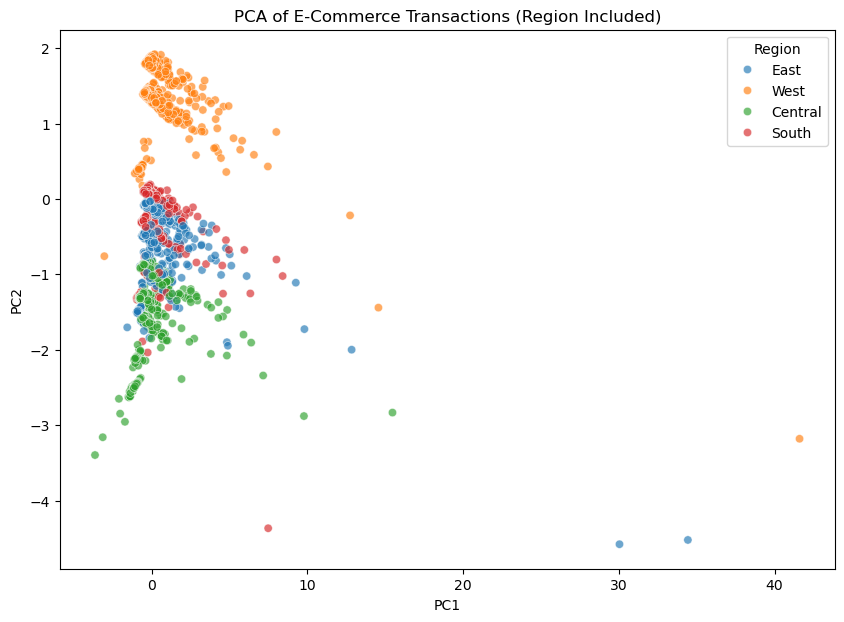

In [34]:
df_scores = pd.DataFrame(
    X_pca[:, :2],
    columns=['PC1','PC2']
)

df_scores['Region'] = df_pca['Region'].values

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_scores,
    x='PC1',
    y='PC2',
    hue='Region',
    alpha=0.65
)

plt.title("PCA of E-Commerce Transactions (Region Included)")
plt.show()

In [35]:
#MODELING START using 'region'
df_model = df[[
    'Sales',
    'Quantity',
    'Discount',
    'Unit Price',
    'Region',
    'Category',
    'Profit'
]].dropna().copy()

#one-hot encode region and category 
X = pd.get_dummies(     #converts categorical into OWN COLUMN for each category (true or false)
    df_model[['Sales','Quantity','Discount','Unit Price','Region','Category']],
    drop_first=False
)
y = df_model['Profit']

X

,Sales,Quantity,Discount,Unit Price,Region_Central,Region_East,Region_South,Region_West,Category_Furniture,Category_Office Supplies,Category_Technology
0,48.896,4,0.2,12.224,False,True,False,False,True,False,False
1,474.430,11,0.0,43.130,False,False,False,True,True,False,False
2,3.600,2,0.0,1.800,True,False,False,False,False,True,False
3,454.560,5,0.2,90.912,True,False,False,False,False,True,False
4,141.420,5,0.6,28.284,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3307,90.930,7,0.0,12.990,False,True,False,False,False,False,True
3308,52.776,3,0.2,17.592,False,True,False,False,False,True,False
3309,13.904,2,0.2,6.952,False,False,False,True,False,True,False
3310,20.720,2,0.2,10.360,False,False,False,True,False,True,False


In [36]:
#train,test,split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0
)

#linear regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = make_pipeline(
    StandardScaler(with_mean=False),
    LinearRegression()
)

#make lin model
lin_model.fit(X_train, y_train)

#predict using linmodel
y_pred_lin = lin_model.predict(X_test)

#metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression")
print("RMSE:", rmse_lin)
print("R²:", r2_lin)

Linear Regression
RMSE: 155.53427786718848
R²: 0.22504043427394216


In [37]:
#ridge regression
from sklearn.linear_model import RidgeCV

ridge_model = make_pipeline(
    StandardScaler(with_mean=False),
    RidgeCV(alphas=[0.1,1,10,100])
)
#make ridge
ridge_model.fit(X_train,y_train)
#predict using ridge
y_pred_ridge = ridge_model.predict(X_test)

#metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test,y_pred_ridge))
r2_ridge = r2_score(y_test,y_pred_ridge)

print("Ridge Regression")
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression
RMSE: 154.7767353484348
R²: 0.23257105910578402


In [38]:
#random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=0)

#make params
param_dist = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

#make RS-CV
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=0,
    n_jobs=-1
)
#fit RS-CV
rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

#predict using RS-CV
y_pred_rf = best_rf.predict(X_test)

#metrics
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("R²:", r2_rf)
print(rf_search.best_params_)

Random Forest
RMSE: 91.22090590213472
R²: 0.7334273613973563
{'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 10}


In [39]:
#gradient boost
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=0)

gb.fit(X_train,y_train)

y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test,y_pred_gb))
r2_gb = r2_score(y_test,y_pred_gb)

print("Gradient Boosting")
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting
RMSE: 74.53902746077694
R²: 0.8220105532346988


In [40]:
# importances
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

Sales                       0.609029
Unit Price                  0.267201
Discount                    0.091954
Quantity                    0.009964
Region_Central              0.005327
Category_Furniture          0.005096
Region_East                 0.003852
Category_Office Supplies    0.003280
Region_South                0.001480
Category_Technology         0.001473
dtype: float64

In [41]:
#results table 
results = pd.DataFrame({
    'Model':['Linear','Ridge','Random Forest','Gradient Boosting'], #column names
    'RMSE':[rmse_lin, rmse_ridge, rmse_rf, rmse_gb], 
    'R2':[r2_lin, r2_ridge, r2_rf, r2_gb]
})

results.sort_values('RMSE') 

,Model,RMSE,R2
3,Gradient Boosting,74.539027,0.822011
2,Random Forest,91.220906,0.733427
1,Ridge,154.776735,0.232571
0,Linear,155.534278,0.225040


## THESE ANALYSES BELOW ARE NOT DONE WITH 'REGION'


Text(0.5, 1.0, 'Correlation Heatmap of US E-Commerce Dataset')

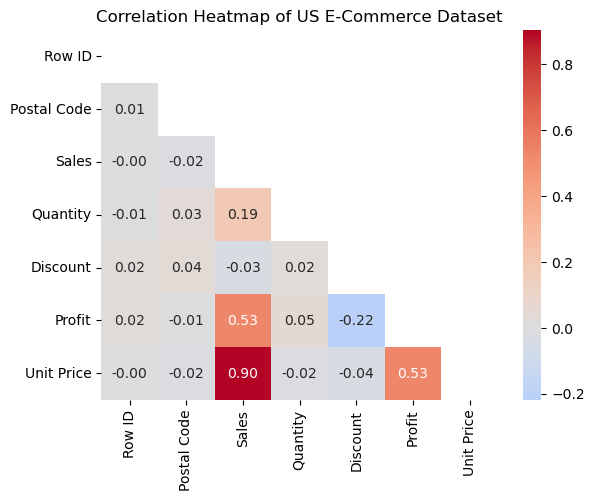

In [42]:

# 1) Multivariate Analysis
#heatmap, bubble, PCA, pairplot, etc.

#Heatmap    
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, center=0, fmt='.2f')
plt.title('Correlation Heatmap of US E-Commerce Dataset')

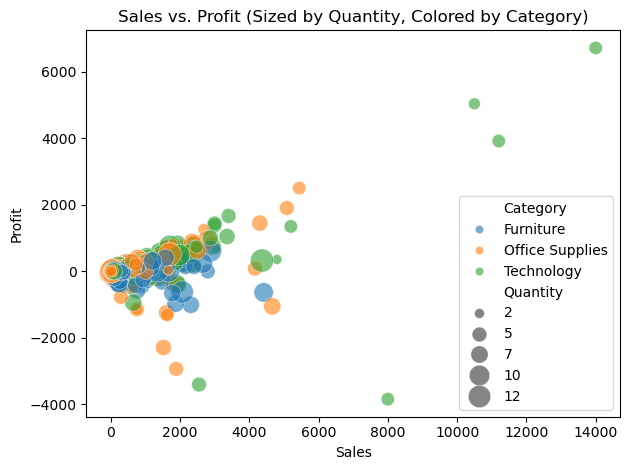

In [43]:
#Bubble Plot (Sales vs. Profit sized by Quantity, colored by Category)
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    size='Quantity',
    hue='Category',
    sizes=(30,300),
    alpha=0.6
)
plt.title('Sales vs. Profit (Sized by Quantity, Colored by Category)')
plt.tight_layout()

In [44]:
df[df['Profit']<-3000]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price
602,17-04-20,3012,CA-2017-134845,Standard Class,SR-20425,Home Office,United States,Louisville,Colorado,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,509.997
2443,04-11-20,684,US-2017-168116,Same Day,GT-14635,Corporate,United States,Burlington,North Carolina,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,1999.995


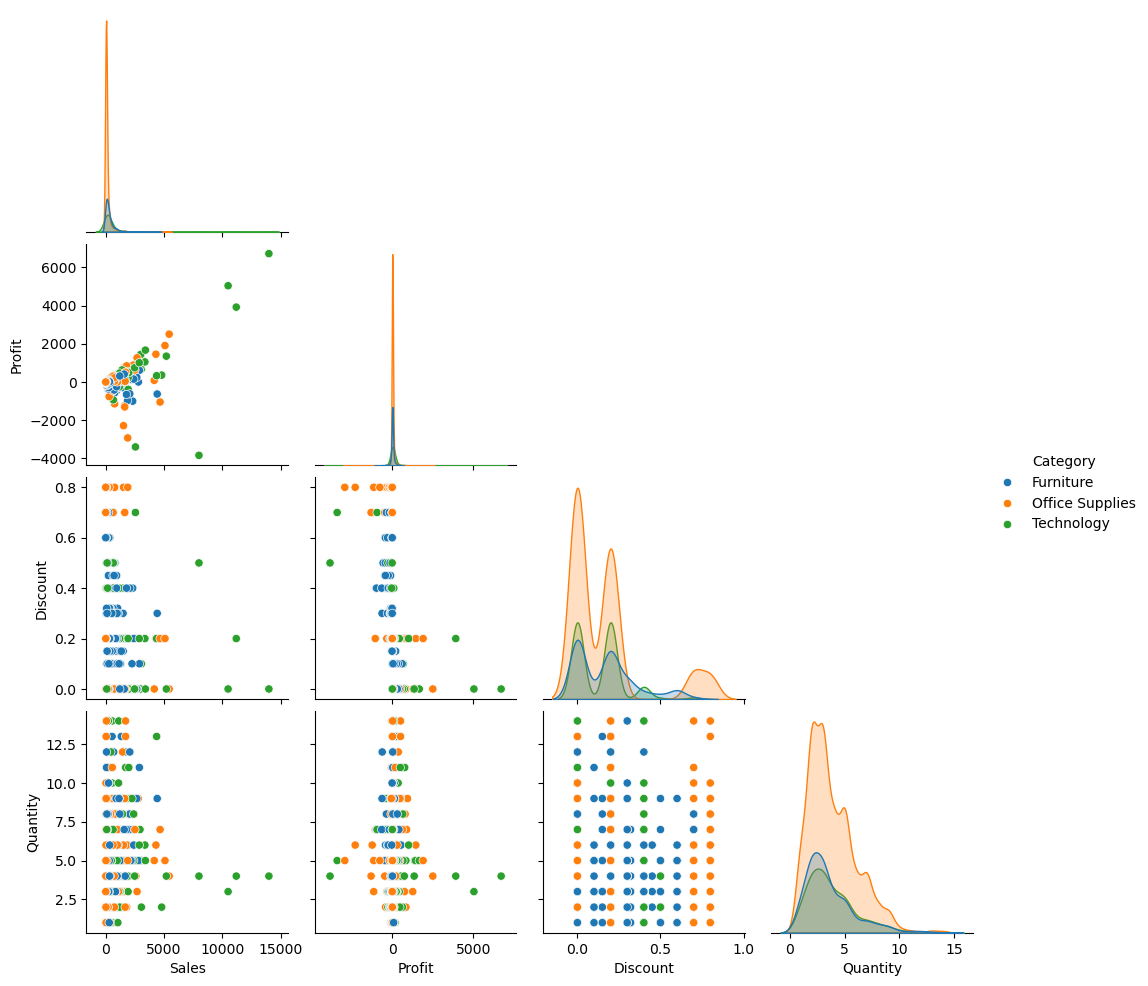

In [45]:
#Pairplot
numcols= [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'Unit Price'
]
df_pair = df[numcols+['Category']]
sns.pairplot(
    df_pair,
    vars=['Sales','Profit','Discount','Quantity'],
    hue='Category',
    corner=True
)

In [46]:
#PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_pca = df[numcols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# build PCA
pca = PCA()
X_scores = pca.fit_transform(X_scaled)

#find explained variance and cumsum
explained = pd.Series(
    pca.explained_variance_ratio_,
    index=[f'PC{i}' for i in range(1,len(numcols)+1)]
)

print(explained)
print(explained.cumsum())

PC1    0.472229
PC2    0.213108
PC3    0.197183
PC4    0.103032
PC5    0.014449
dtype: float64
PC1    0.472229
PC2    0.685336
PC3    0.882519
PC4    0.985551
PC5    1.000000
dtype: float64


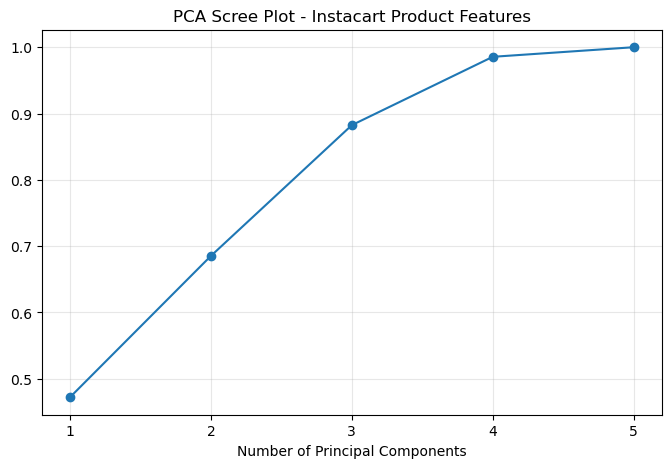

                 PC1       PC2       PC3       PC4       PC5
Sales       0.609352  0.180195 -0.055284 -0.310929  0.704618
Quantity    0.095608  0.555613  0.810490  0.005298 -0.158842
Discount   -0.110401  0.778629 -0.522799  0.328982  0.000505
Profit      0.495848 -0.222454  0.089217  0.834672  0.003399
Unit Price  0.601245  0.055455 -0.242426 -0.313669 -0.691571


In [47]:
#Scree Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(numcols)+1), explained.cumsum(), marker='o')
plt.xlabel("Number of Principal Components")
plt.title("PCA Scree Plot - Instacart Product Features")
plt.xticks(range(1, len(numcols)+1))
plt.grid(alpha=0.3)
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=numcols,
    columns=[f'PC{i}' for i in range(1, len(numcols)+1)]
)

print(loadings)

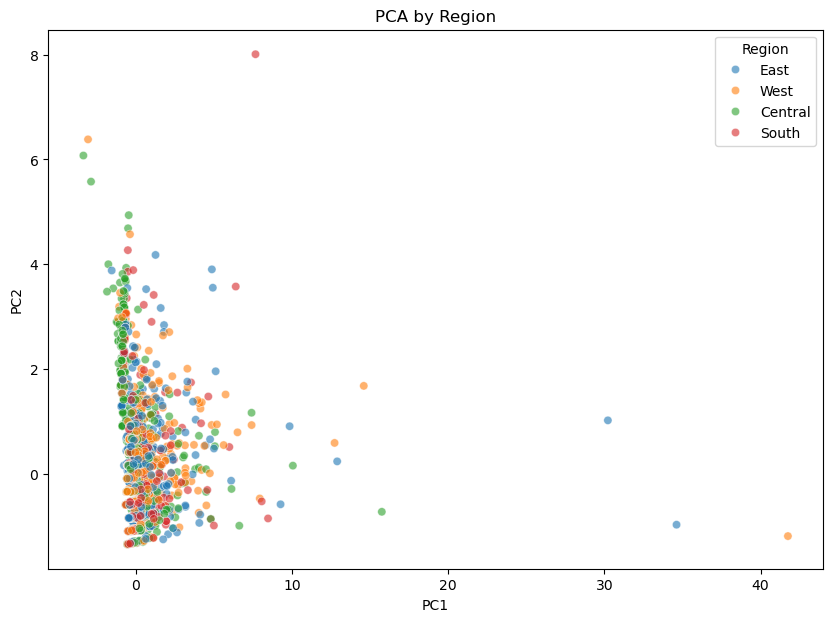

In [48]:
df_scores = pd.DataFrame(X_scores[:, :2], columns=['PC1','PC2'])
df_scores['Region'] = df.loc[X_pca.index, 'Region'].values

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_scores,
    x='PC1',
    y='PC2',
    hue='Region',
    alpha=0.6
)

plt.title("PCA by Region")
plt.show()

In [49]:
#2) Modeling 
features = [
    'Sales',
    'Quantity',
    'Discount',
    'Unit Price'
]

target = 'Profit'

X = df[features]
y = df[target]

# train, test, split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)
#2a) Linear Regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lin_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)
#build lin model
lin_model.fit(X_train, y_train)

#predict using lin model
y_pred_lin = lin_model.predict(X_test)

#calculate metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression RMSE:", rmse_lin)
print("Linear Regression R²:", r2_lin)


Linear Regression RMSE: 156.4905024543324
Linear Regression R²: 0.21548224114238435


In [50]:
#2b) Random Forest w/ CV, hyperparameter tuning, metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=0)

#build param_dist
param_dist = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

#build RS-CV
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=0,
    n_jobs=-1
)

#fit RS-CV
rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

#predict using built rs-cv
y_pred_rf = best_rf.predict(X_test)

#metrics
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)
print(rf_search.best_params_)


Random Forest RMSE: 94.15557848881727
Random Forest R²: 0.7159996200421046
{'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 10}


In [51]:
#feature importance
importances = pd.Series(
    best_rf.feature_importances_,
    index=features,
).sort_values(ascending=False)

print(importances)
print()
#comparison
print("Linear RMSE:", rmse_lin)
print("Random Forest RMSE:", rmse_rf)
print("Linear Regression R²:", r2_lin)
print("Random Forest R²:", r2_rf)

#create dataframe comparing the two
comparisondf = pd.DataFrame({
    'linear model':[rmse_lin, r2_lin], #column name with all row values
    'random forest model': [rmse_rf, r2_rf]
},index = ['RMSE values', 'r2 values'])

comparisondf


Sales         0.603902
Unit Price    0.284916
Discount      0.098080
Quantity      0.013101
dtype: float64

Linear RMSE: 156.4905024543324
Random Forest RMSE: 94.15557848881727
Linear Regression R²: 0.21548224114238435
Random Forest R²: 0.7159996200421046


,linear model,random forest model
RMSE values,156.490502,94.155578
r2 values,0.215482,0.716000


<br><br>
---
# 📊 Mod C1 CAPSTONE Milestone 1 START -> More Modeling



---

### X = categories of df_model 'Sales','Quantity','Discount','Unit Price','Region','Category' 
y = df_model['Profit']

In [52]:
display (df.head(3), df_model)

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,12.224
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,43.130
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,1.800


,Sales,Quantity,Discount,Unit Price,Region,Category,Profit
0,48.896,4,0.2,12.224,East,Furniture,8.5568
1,474.430,11,0.0,43.130,West,Furniture,199.2606
2,3.600,2,0.0,1.800,Central,Office Supplies,1.7280
3,454.560,5,0.2,90.912,Central,Office Supplies,-107.9580
4,141.420,5,0.6,28.284,Central,Furniture,-187.3815
...,...,...,...,...,...,...,...
3307,90.930,7,0.0,12.990,East,Technology,2.7279
3308,52.776,3,0.2,17.592,East,Office Supplies,19.7910
3309,13.904,2,0.2,6.952,West,Office Supplies,4.5188
3310,20.720,2,0.2,10.360,West,Office Supplies,6.4750


## Week 1 - Linear Regression 


In [53]:
#Lin regression again using 'region'
df_model = df[[
    'Sales',
    'Quantity',
    'Discount',
    'Unit Price',
    'Region',
    'Category',
    'Profit'
]].dropna().copy()

#one-hot encode region and category 
X = pd.get_dummies(     #converts categorical into OWN COLUMN for each category (true or false)
    df_model[['Sales','Quantity','Discount','Unit Price','Region','Category']],
    drop_first=False
)
y = df_model['Profit']

X

,Sales,Quantity,Discount,Unit Price,Region_Central,Region_East,Region_South,Region_West,Category_Furniture,Category_Office Supplies,Category_Technology
0,48.896,4,0.2,12.224,False,True,False,False,True,False,False
1,474.430,11,0.0,43.130,False,False,False,True,True,False,False
2,3.600,2,0.0,1.800,True,False,False,False,False,True,False
3,454.560,5,0.2,90.912,True,False,False,False,False,True,False
4,141.420,5,0.6,28.284,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3307,90.930,7,0.0,12.990,False,True,False,False,False,False,True
3308,52.776,3,0.2,17.592,False,True,False,False,False,True,False
3309,13.904,2,0.2,6.952,False,False,False,True,False,True,False
3310,20.720,2,0.2,10.360,False,False,False,True,False,True,False


In [54]:
#train,test,split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0
)

#linear regression START
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = make_pipeline(
    StandardScaler(with_mean=False),
    LinearRegression()
)

#make lin model
lin_model.fit(X_train, y_train)

#predict using linmodel
y_pred_lin = lin_model.predict(X_test)

#metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression")
print("RMSE:", rmse_lin)
print("R²:", r2_lin)

Linear Regression
RMSE: 155.53427786718848
R²: 0.22504043427394216


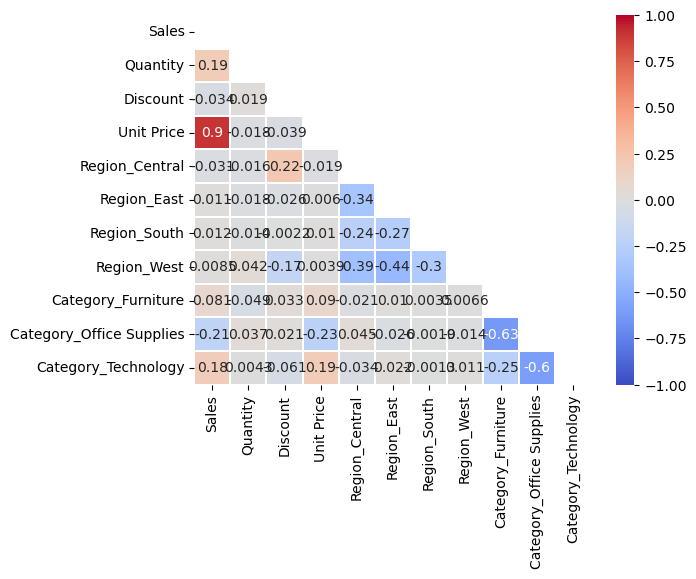

In [55]:
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            linewidths=0.3, vmin=-1, vmax=1)
plt.show()

## Week 2 - Lasso, Ridge, Elastic Net


In [56]:
#1) LASSO MODEL - start

#MODEL -> Lasso Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=0, max_iter=10000)
)

# CV RMSE
cv_scores = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Lasso Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
lasso_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = lasso_model.named_steps['lassocv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = lasso_model.predict(X_test)

#Metrics
l_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
l_r2 = r2_score(y_test, y_pred)
print("Lasso Regression Test RMSE:", l_rmse)
print("Lasso Regression Test R2:", l_r2)




Lasso Regression CV RMSE: 183.60318151707602
best alpha: 0.14229182632541404
Lasso Regression Test RMSE: 155.4911205410716
Lasso Regression Test R2: 0.22547044292559515


In [57]:
#2) RIDGE REGRESSION MODEL - start

#MODEL -> Ridge Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4,4,100),cv=5)
        #! FIND BEST ALPHA on log scale so 100 values between 10^-4 and 10^4 
)

# CV RMSE
cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Ridge Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
ridge_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = ridge_model.named_steps['ridgecv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = ridge_model.predict(X_test)

#Metrics
r_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_r2 = r2_score(y_test, y_pred)
print("Ridge Regression Test RMSE:", r_rmse)
print("Ridge Regression Test R2:", r_r2)


Ridge Regression CV RMSE: 181.94975467174518
best alpha: 890.2150854450392
Ridge Regression Test RMSE: 153.17451008146722
Ridge Regression Test R2: 0.2483774366151008


In [58]:
#3) ELASTIC NET REGRESSION MODEL - start

#MODEL -> elastic net Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=np.logspace(-4,4,100),
                 l1_ratio=[0.1,0.5,0.7,0.9,1.0],
                #! HERE FIND BEST RATIO (0.0 L2 ridge vs. 1.0 L1 lasso)
                 cv=5)
    
)

# CV RMSE
cv_scores = cross_val_score(
    elastic_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("ElasticNet Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
elastic_model.fit(X_train, y_train)

#FIND BEST L1 RATIO value -> using .named_steps
bestratio = elastic_model.named_steps['elasticnetcv'].l1_ratio_
print('best ratio:', bestratio)
            #note = best ratio = 0.1 (closer to R2 ridge)
#Predict using X_test
y_pred = elastic_model.predict(X_test)

#Metrics
e_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
e_r2 = r2_score(y_test, y_pred)
print("ElasticNet Regression Test RMSE:", e_rmse)
print("ElasticNet Regression Test R2:", e_r2)


ElasticNet Regression CV RMSE: 181.11160147612128
best ratio: 0.1
ElasticNet Regression Test RMSE: 154.04668720346257
ElasticNet Regression Test R2: 0.2397935756044719


In [59]:
comparisondf = pd.DataFrame({
"Lasso":[l_rmse, l_r2],
"Ridge":[r_rmse, r_r2],
'ElasticNet': [e_rmse, e_r2]
},index=['RMSE', 'R2'])
comparisondf

,Lasso,Ridge,ElasticNet
RMSE,155.491121,153.174510,154.046687
R2,0.225470,0.248377,0.239794


## Week 3 - Fwd/Back Selection, PCR, PLSR


In [60]:
#3A1) Fwd Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs_for = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='forward',
    cv=5
)

sfs_for.fit(X, y)

selected_features = X.columns[sfs_for.get_support()]
print(selected_features)


Index(['Quantity', 'Discount', 'Unit Price', 'Region_West',
       'Category_Furniture'],
      dtype='object')


In [61]:
#3A2) Backward Selection
sfs_back = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='backward',
    cv=5
)

#fit model
sfs_back.fit(X,y)
selected_features = X.columns[sfs_back.get_support()]
print(selected_features)

Index(['Quantity', 'Discount', 'Unit Price', 'Category_Furniture',
       'Category_Office Supplies', 'Category_Technology'],
      dtype='object')


In [62]:
#3B) PCR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#create pcr PIPELINE
pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),   #keep only top 2 PCs
    ('lr', LinearRegression()) 
])

pcr.fit(X_train, y_train) #lin reg fits Y ~ PC1 + PC2

y_pred = pcr.predict(X_test)

print("PCR R2:", r2_score(y_test, y_pred))

PCR R2: 0.09118881556720859


In [63]:
#Explained Variance Ratio for PC's
pca = PCA()
pca.fit(StandardScaler().fit_transform(X))

print(pca.explained_variance_ratio_.round(4))

[0.206  0.1402 0.1345 0.1262 0.1108 0.11   0.0904 0.0754 0.0066 0.
 0.    ]


In [64]:
#3B) PCR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#create pcr PIPELINE
pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),   #keep only top 2 PCs
    ('lr', LinearRegression()) 
])

pcr.fit(X_train, y_train) #lin reg fits Y ~ PC1 + PC2

y_pred = pcr.predict(X_test)

print("PCR R2:", r2_score(y_test, y_pred))

PCR R2: 0.09118881556720859


## Week 4 - Logistic Regression, Feature Scaling


1) "Can we predict which region an order came from" (multiclass logistical regression)

In [65]:
#Predict region, based on sales, discount, category, etc.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X_logist = X.drop(columns=['Region_Central','Region_East','Region_South','Region_West']) #done pd.get_dummies 
y=df['Region']

display (X_logist)
#Train,test,split
X_train, X_test, y_train, y_test = train_test_split(
    X_logist,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

#Make Logistic Regression
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=0
    )
)
#fit model
log_model.fit(X_train,y_train)

#predictions on X_test
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test) #NEED ALL 4 COLUMNS b/c multiclass, no [:,1]

#metrics
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='macro', zero_division=np.nan))
print("Recall   :", recall_score(y_test, y_pred_log, average='macro'))  #MACRO = averages all 4 regions values
print("F1 Score :", f1_score(y_test, y_pred_log, average='macro'))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log, multi_class='ovr')) #one vs. rest, average of x4 times bc 4 regions !!


,Sales,Quantity,Discount,Unit Price,Category_Furniture,Category_Office Supplies,Category_Technology
0,48.896,4,0.2,12.224,True,False,False
1,474.430,11,0.0,43.130,True,False,False
2,3.600,2,0.0,1.800,False,True,False
3,454.560,5,0.2,90.912,False,True,False
4,141.420,5,0.6,28.284,True,False,False
...,...,...,...,...,...,...,...
3307,90.930,7,0.0,12.990,False,False,True
3308,52.776,3,0.2,17.592,False,True,False
3309,13.904,2,0.2,6.952,False,True,False
3310,20.720,2,0.2,10.360,False,True,False


===== Logistic Regression =====
Accuracy : 0.3559577677224736
Precision: 0.3413933731950429
Recall   : 0.28833793390449136
F1 Score : 0.2315587875214818
ROC AUC: 0.5587078397890418


array(['Central', 'East', 'South', 'West'], dtype=object)

array([[1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       ...,
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 0, 1]], shape=(663, 4))

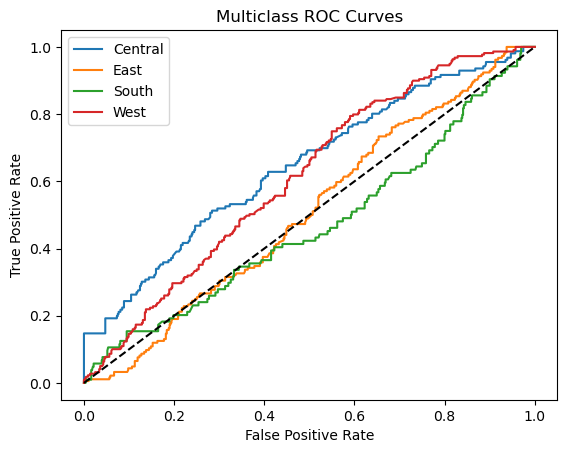

In [66]:
#Plot multiclass 4 regions ROC curves
from sklearn.preprocessing import label_binarize        #USE THIS figure maybe 
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

classes = log_model.classes_
display (classes)   

#takes matrix of y_test and changes region binary 1 or 0 for each sample
y_test_bin = label_binarize(y_test, classes=classes)    #just changes 4 regions into binary 1 or 0
display (y_test_bin)

y_prob = log_model.predict_proba(X_test)

for i, region in enumerate(classes):    #for loop so plots curve for 4 regions
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])     #(y_true, y_pred)

    plt.plot(fpr, tpr, label=region)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()


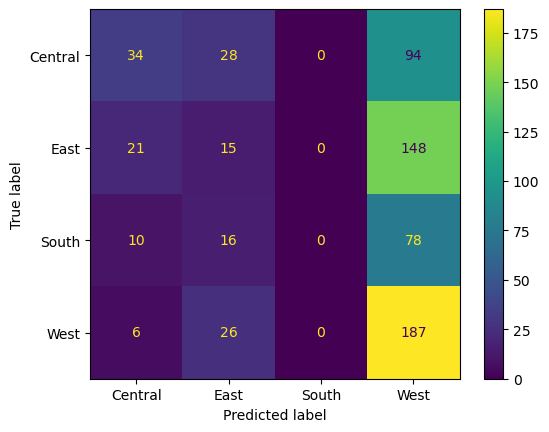

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.show()

2.) Can we predict whether an order is profitable?

In [68]:
#2nd Logistic Regression with "profitable" binary column
profitdf = df.copy()
profitdf['profitable']= (profitdf['Profit']>0).astype(int)  #boolean value and then integer binary 
profitdf.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price,profitable
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,...,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,12.224,1
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,...,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,43.130,1
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,...,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,1.800,1
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580,90.912,0
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,...,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815,28.284,0


In [128]:
#note 80% of orders are already profitable  -> want model prediction >80% 
profitdf['profitable'].value_counts(normalize=True)

profitable
1    0.807065
0    0.192935
Name: proportion, dtype: float64

In [132]:
# Create profit_X feature matrix for ALL classification models
profit_X = pd.get_dummies(
    df[
        [
            'Sales',
            'Quantity',
            'Discount',
            'Unit Price',
            'Region',
            'Category'
        ]
    ],
    drop_first=True #prevent dummy variable trap
)

profit_X.head()

,Sales,Quantity,Discount,Unit Price,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,48.896,4,0.2,12.224,True,False,False,False,False
1,474.430,11,0.0,43.130,False,False,True,False,False
2,3.600,2,0.0,1.800,False,False,False,True,False
3,454.560,5,0.2,90.912,False,False,False,True,False
4,141.420,5,0.6,28.284,False,False,False,False,False


- Region CENTRAL is reference region
- Category FURNITURE is reference category 

In [133]:
#predict 'profitable'  (using discount, price, and each region too)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

y = profitdf['profitable']

#Train,test,split
X_train, X_test, y_train, y_test = train_test_split(
    profit_X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

#Make Logistic Regression
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=0
    )
)
#fit model
log_model.fit(X_train,y_train)

#predictions on X_test
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1] # remember 'profitable' is binary so use [:,1]

#metrics
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log)) 
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

===== Logistic Regression =====
Accuracy : 0.9396681749622926
Precision: 0.9334500875656743
Recall   : 0.9962616822429906
F1 Score : 0.9638336347197106
ROC AUC: 0.963879964953271


AUC: 0.963879964953271


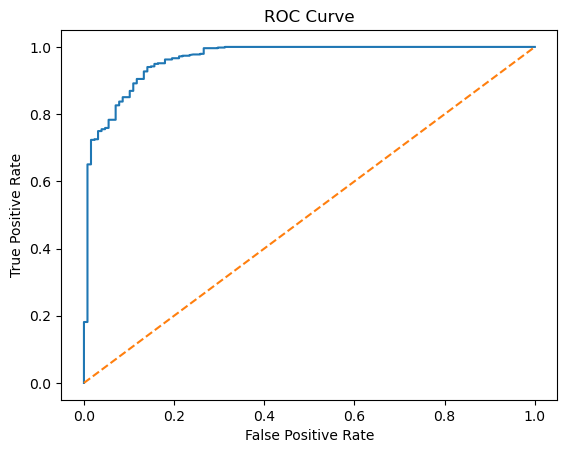

In [141]:
#GRAPH logistic model
from sklearn.metrics import roc_curve, auc

#logistic probs predict on X_test, remember 1st column is prob(Y=1), 2nd (Y=0)
y_prob_log = log_model.predict_proba(X_test)[:,1] #list of all probabilities predicted from model ! 

#create ROC curve with fpr, tpr
fpr, tpr,_ = roc_curve(y_test, y_prob_log)   #_ because dont need 3rd item thresholds

#plot ROC curve
plt.plot(fpr, tpr)

#plot y=x line
plt.plot([0,1],[0,1],'--')

#labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

#results
print(
    'AUC:', roc_auc_score(y_test, y_prob_log)
)
plt.show()

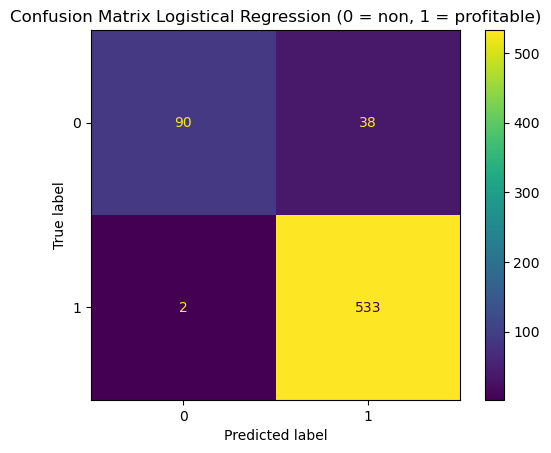

In [142]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title('Confusion Matrix Logistical Regression (0 = non, 1 = profitable)')
plt.show()

2b) EDA of regions sorted by profitable

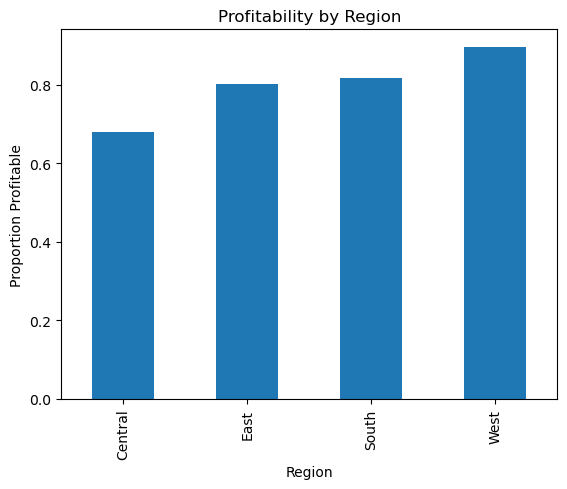

In [143]:
#bar graph profitability by region
profitdf.groupby('Region')['profitable'].mean().sort_values().plot(kind='bar')
plt.ylabel('Proportion Profitable')
plt.title('Profitability by Region')
plt.show()

## Week 5 - SVM, Kernel Trick, Regularization of Support Vector Machines


In [144]:
from sklearn.svm import SVC 

# SVM with linear kernel
svm_linear = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=1, probability=True, random_state=0)
)

svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)
y_prob_svm = svm_linear.predict_proba(X_test)[:, 1]

print("===== Linear SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Linear SVM =====
Accuracy : 0.9396681749622926
Precision: 0.9334500875656743
Recall   : 0.9962616822429906
F1 Score : 0.9638336347197106
ROC AUC  : 0.9515259929906542


In [145]:
# SVM with RBF kernel  
svm_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=0)
)

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("===== RBF Kernel SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall   :", recall_score(y_test, y_pred_rbf))
print("F1 Score :", f1_score(y_test, y_pred_rbf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rbf))

===== RBF Kernel SVM =====
Accuracy : 0.9396681749622926
Precision: 0.9319371727748691
Recall   : 0.9981308411214953
F1 Score : 0.9638989169675091
ROC AUC  : 0.9631352219626168


In [146]:
#Regularization SVM with random search and tuning C 
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svm_pipe = make_pipeline(
    StandardScaler(),
    SVC(random_state=0)
)

param_dist = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.1]
}

svm_search = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=0,
    n_jobs=1
)

svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)

Best params: {'svc__kernel': 'linear', 'svc__gamma': 0.1, 'svc__C': 1}


In [147]:
#now test model with best parameters
best_params = svm_search.best_params_

best_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel=best_params['svc__kernel'],
        C=best_params['svc__C'],
        gamma=best_params['svc__gamma'],
        probability=True,
        random_state=0
    )
)
#fit model
best_svm.fit(X_train, y_train)

#y_pred and y_prob
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

best_svm.fit(X_train, y_train)
print("===== Best SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Best SVM =====
Accuracy : 0.9396681749622926
Precision: 0.9334500875656743
Recall   : 0.9962616822429906
F1 Score : 0.9638336347197106
ROC AUC  : 0.9515259929906542


## Week 6 - Decision Trees, Random Forests


In [148]:
#1) Decision Tree w/ randomized search and CV
dt = DecisionTreeClassifier(random_state=0)

#a) make params
param_dist = {
    'ccp_alpha': [0.0, 0.001, 0.01,  0.05, 0.1],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10,15],
    'min_samples_leaf': [1,2,5,10]
}

#b) make RS-CV
dt_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=0,
    n_jobs=-1
)
#c) fit RS-CV
dt_search.fit(X_train,y_train)

best_dt = dt_search.best_estimator_

#d) predict using RS-CV
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:,1]

#e) metrics
rmse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))
r2_dt = r2_score(y_test,y_pred_dt)

print("===== Decision Tree =====")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))


===== Decision Tree =====
Accuracy : 0.9396681749622926
Precision: 0.9334500875656743
Recall   : 0.9962616822429906
F1 Score : 0.9638336347197106
ROC AUC  : 0.8496933411214953


In [149]:
#2) random forest with randomized search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=0)

#make params
param_dist = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

#make RS-CV
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=0,
    n_jobs=-1
)
#fit RS-CV
rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

#predict using RS-CV

#metrics
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

#e) metrics

print("===== Random Forest  =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))


===== Random Forest  =====
Accuracy : 0.9532428355957768
Precision: 0.9565217391304348
Recall   : 0.9869158878504672
F1 Score : 0.9714811407543699
ROC AUC  : 0.9853752920560748


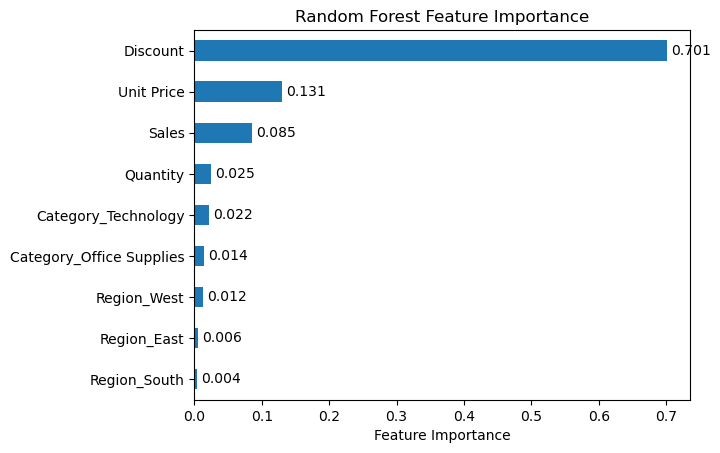

In [150]:
#feature importances graph          remember -> dummy variable trap, central gone so is baseline, coefficients scale to that
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values()

ax = importance.plot(kind='barh')

# add labels to each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

## !Week 8 - K-Nearest Neighbors / Distance Metrics



- profit_X = pd.get_dummies(
    for all these 'Sales','Quantity','Discount','Unit Price','Region','Category'

- y = profitdf['profitable']

- BUT DISTANCE METRICS USE knn_X bc LOG SCALED


In [151]:
profitdf['profitable'].value_counts()

#2673 / 3312 = 80.7% already profitable as baseline

profitable
1    2673
0     639
Name: count, dtype: int64

In [242]:
#LOG SCALE FEATURES first

# Prepare Distance-based KNN features
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
knn_X = df[
    [
        'Sales',
        'Quantity',
        'Discount',
        'Unit Price',
        'Region',
        'Category'
    ]
].copy()

# Log-transform heavily right-skewed numeric features
knn_X['Sales'] = np.log1p(knn_X['Sales'])
knn_X['Unit Price'] = np.log1p(knn_X['Unit Price'])

# One-hot encode categorical features
knn_X = pd.get_dummies(
    knn_X,
    columns=['Region', 'Category'],
    drop_first=True,
    dtype=int
)

# Binary target
y = profitdf['profitable']

# Split AFTER all feature engineering
X_train, X_test, y_train, y_test = train_test_split(
    knn_X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

In [243]:
# 1) KNN CLASSIFICATION

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = []    # list of results per distance metric

# compare 3 distance metrics
metrics = {
    "Manhattan": ("minkowski", 1),
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

# loop through each distance metric
for name, (metric, p) in metrics.items():

    knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            metric=metric,
            p=p
        ))
    ])

    param_dist = {
        'knn__n_neighbors': [3, 5, 10, 15, 20, 30, 50],
        'knn__weights': ['uniform', 'distance']
    }

    # randomized search with cross-validation
    knn_search = RandomizedSearchCV(
        knn,
        param_distributions=param_dist,
        n_iter=5,
        cv=5,
        scoring='roc_auc',
        random_state=0,
        n_jobs=-1
    )

    # fit model
    knn_search.fit(X_train, y_train)

    # predictions
    y_pred = knn_search.best_estimator_.predict(X_test)
    y_prob = knn_search.best_estimator_.predict_proba(X_test)[:, 1]

    # save results
    results.append({
        'Distance': name,
        'Best K': knn_search.best_params_['knn__n_neighbors'],
        'Weights': knn_search.best_params_['knn__weights'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

knn_results = pd.DataFrame(results)

knn_results

,Distance,Best K,Weights,Accuracy,Precision,Recall,F1,ROC-AUC
0,Manhattan,20,uniform,0.941176,0.941281,0.988785,0.964448,0.973408
1,Euclidean,15,uniform,0.942685,0.946140,0.985047,0.965201,0.969772
2,Minkowski (p=3),15,uniform,0.939668,0.944345,0.983178,0.963370,0.970218


- analysis
- Amazon dataset ALSO had worse change ROC rf 0.692 -> knn 0.668 
- E-commerce here 0.985 -> 0.970 so WORSE ROC from knn
- ecomm dt = 0.849 -> rf .985 huge jump!

In [244]:
# ==========================================
# 1B) Table of ROC-AUC and F1 vs. K

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# values of k to test
k_values = [3, 5, 10, 15, 20, 30, 50]

# distance metrics to compare
metrics = {
    "Manhattan": ("minkowski", 1),
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

plot_results = []

# test every distance metric and k value
for distance_name, (metric, p) in metrics.items():
    
    for k in k_values:
        knn = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(
                n_neighbors=k,
                weights='uniform',
                metric=metric,
                p=p
            ))
        ])

        # fit model
        knn.fit(X_train, y_train)

        # predicted classes and probabilities
        y_pred = knn.predict(X_test)
        y_prob = knn.predict_proba(X_test)[:, 1]

        # save results
        plot_results.append({
            'Distance': distance_name,
            'K': k,
            'F1': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        })

knn_plot_results = pd.DataFrame(plot_results)

knn_plot_results.sort_values(by='ROC-AUC', ascending=False)

,Distance,K,F1,ROC-AUC
3,Manhattan,15,0.967153,0.976752
4,Manhattan,20,0.964448,0.973408
2,Manhattan,10,0.967742,0.973051
16,Minkowski (p=3),10,0.962072,0.972437
5,Manhattan,30,0.963702,0.972189
1,Manhattan,5,0.965009,0.971692
11,Euclidean,20,0.961609,0.971488
9,Euclidean,10,0.963989,0.971371
17,Minkowski (p=3),15,0.963370,0.970218
8,Euclidean,5,0.964055,0.969955


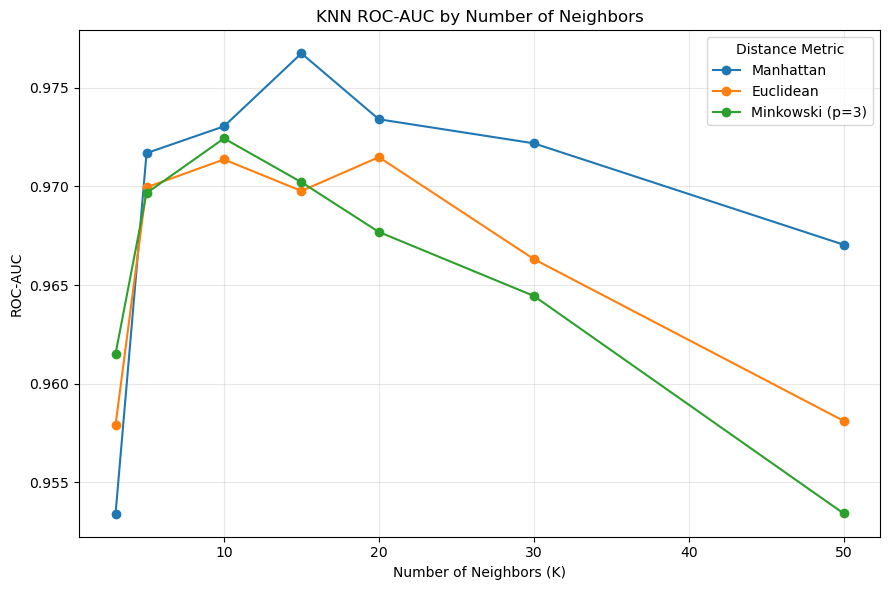

In [245]:
#ROC-AUC vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['ROC-AUC'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('ROC-AUC')
plt.title('KNN ROC-AUC by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- analysis here think

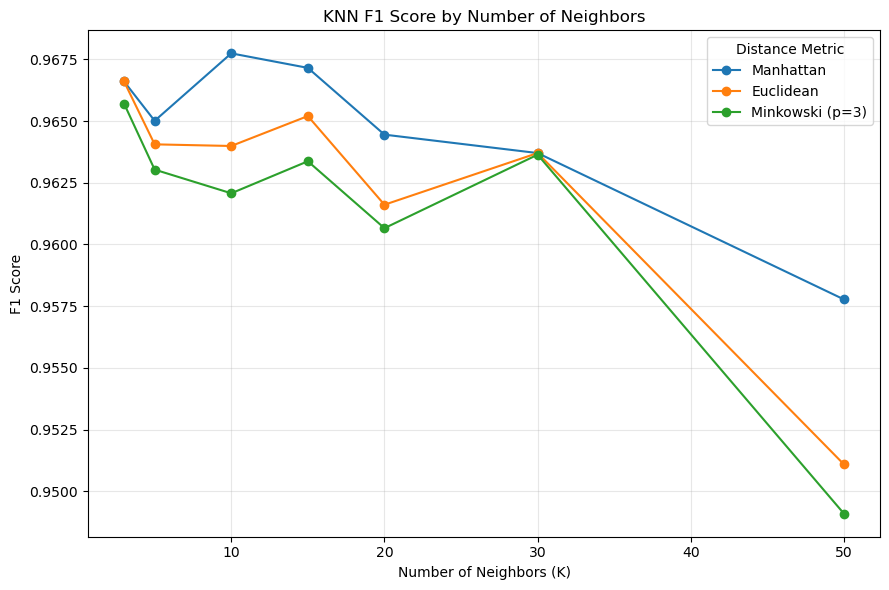

In [246]:
#F1 Score vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['F1'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.title('KNN F1 Score by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- analysis here think

## Week 9 - Gradient Boost
- include learning rate, number of estimators, tree depth, regularization


In [248]:
#1) Gradient boost classification (min runtime)
y = profitdf['profitable']

#split train 80%, test set 20%
X_train, X_test, y_train, y_test = train_test_split(
        knn_X, y, test_size=0.2, random_state=0, stratify=y
    )

gb = GradientBoostingClassifier(random_state=0)

#make params
param_dist = {
    'learning_rate': [0.01, 0.03, 0.1, 0.2, 0.5],
    'n_estimators':[100,200,400,600],
    'max_depth':[2,3,5,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf' : [1,2,5,10],
    'subsample' : [0.6, 0.8, 1.0],
    'max_features' : ['sqrt', 'log2', None]
}

#make RS-CV estimator
gb_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)

#ITERATE FIND MODEL for each parameter setting using .fit
gb_search.fit(X_train, y_train)
#after done, auto fit one final best parameter model on x_train

#create variable for model with BEST Parameters
best_gb = gb_search.best_estimator_
print('best parameters', gb_search.best_params_)

#Predict using X_test
y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:,1]

#Metrics
gb_accuracy = accuracy_score(y_test, y_pred)
gb_precision = precision_score(y_test, y_pred)
gb_recall = recall_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)
gb_auc = roc_auc_score(y_test, y_prob)

print("GB Classification Test Accuracy:", gb_accuracy)
print("GB Classification Test Precision:", gb_precision)
print("GB Classification Test Recall:", gb_recall)
print("GB Classification Test F1:", gb_f1)
print("GB Classification Test ROC-AUC:", gb_auc)

best parameters {'subsample': 0.6, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10, 'learning_rate': 0.03}
GB Classification Test Accuracy: 0.9547511312217195
GB Classification Test Precision: 0.9599271402550091
GB Classification Test Recall: 0.9850467289719627
GB Classification Test F1: 0.9723247232472325
GB Classification Test ROC-AUC: 0.9865873247663551


- analysis
GB (0.9865) best score slightly better rf (0.9853), MUCH BETTER NOTE dt(0.8496)!

- GB here slightly ROC-AUC better than KNN (0.9755)

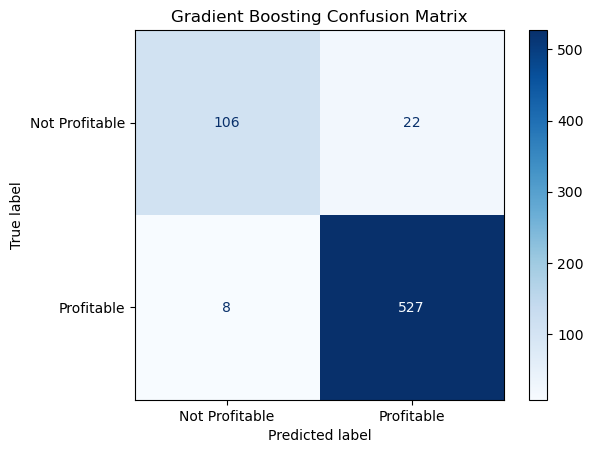

In [249]:
#1B) GB Confusion Matrix for test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Profitable', 'Profitable']
)

cm_display.plot(cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

- worst accuracy 0.95, also small sample size thoguh

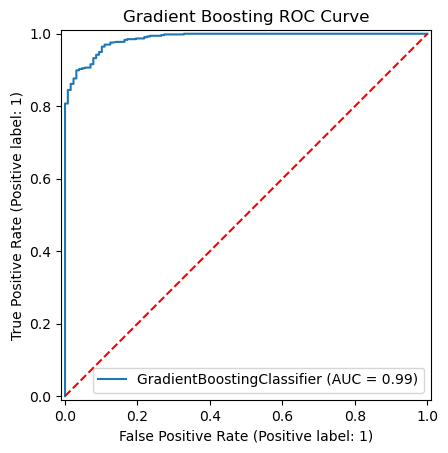

In [250]:
#1C) Plot ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_gb,
    X_test,
    y_test
)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("Gradient Boosting ROC Curve")
plt.show()

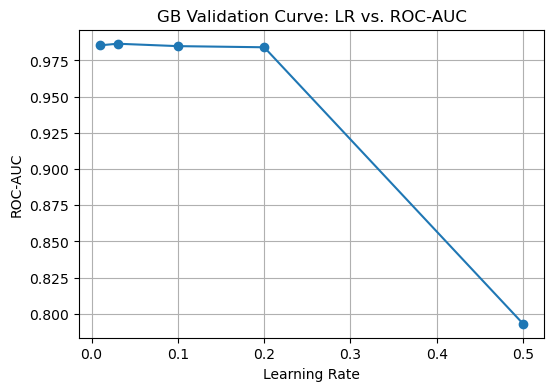

In [251]:
#1D) Validation curve: ROC-AUC vs Learning Rate

learning_rates = [0.01,0.03,0.1,0.2,0.5]
auc_scores = []

for lr in learning_rates:

    gb = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=best_gb.n_estimators,
        max_depth=best_gb.max_depth,
        min_samples_split=best_gb.min_samples_split,
        min_samples_leaf=best_gb.min_samples_leaf,
        subsample=best_gb.subsample,
        max_features=best_gb.max_features,
        random_state=0
    )

    gb.fit(X_train, y_train)

    #Predict using X_test
    y_prob = gb.predict_proba(X_test)[:,1]

    #Save ROC-AUC
    auc_scores.append(
        roc_auc_score(y_test, y_prob)
    )

#Plot validation curve

plt.figure(figsize=(6,4))
plt.plot(learning_rates, auc_scores, marker='o')

plt.xlabel("Learning Rate")
plt.ylabel("ROC-AUC")
plt.title("GB Validation Curve: LR vs. ROC-AUC")

plt.grid(True)
plt.show()

- Both ecommerce and amazon had 0.03 as best LR here


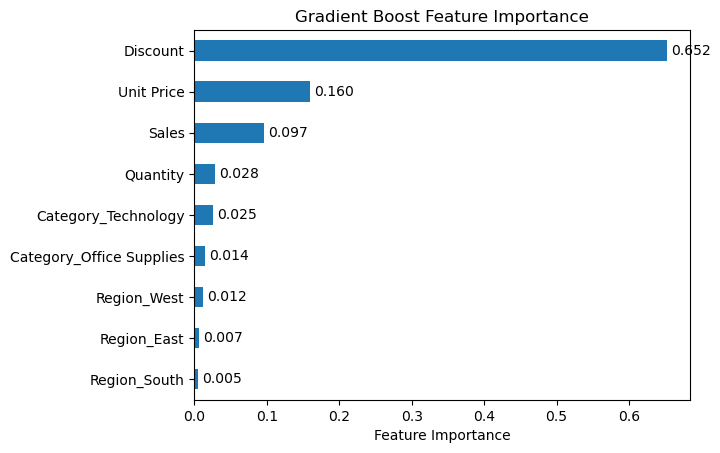

In [252]:
#1E) feature importances graph for GB        
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values()

ax = importance.plot(kind='barh')

# add labels to each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)

plt.xlabel("Feature Importance")
plt.title("Gradient Boost Feature Importance")
plt.show()

- LESS FI for discount here 0.652 vs rf graph (0.701)



Best number of trees: 60
Best validation ROC-AUC: 0.9619525380245556


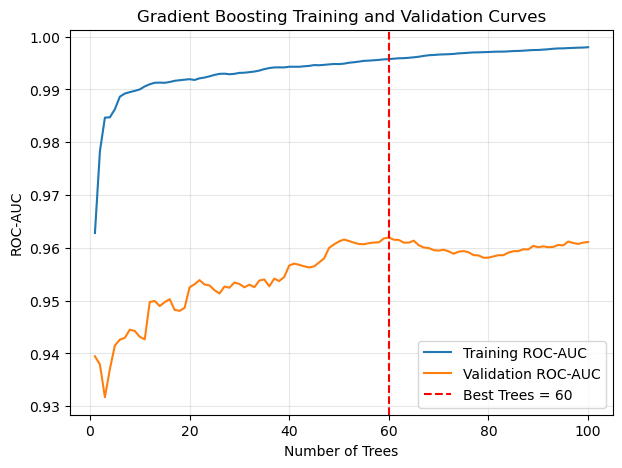

In [269]:
#Training and Validation ROC-AUC vs Number of Trees

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

#split training data again into train and validation
X_gb_train, X_val, y_gb_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train
)

#copy best gradient boosting model
gb_curve = clone(best_gb)

#fit only on new training set
gb_curve.fit(X_gb_train, y_gb_train)

#empty lists for train vs validation scores
train_auc = []
val_auc = []

#find predictions after each new tree
for train_prob, val_prob in zip(
    gb_curve.staged_predict_proba(X_gb_train),
    gb_curve.staged_predict_proba(X_val)
):
    #add score to list
    train_auc.append(
        roc_auc_score(y_gb_train, train_prob[:,1])
    )
    #add score to list
    val_auc.append(
        roc_auc_score(y_val, val_prob[:,1])
    )

#number of trees
trees = range(1, len(train_auc) + 1)

#find tree with highest validation ROC-AUC
best_tree = np.argmax(val_auc) + 1
best_val_auc = max(val_auc)

print("Best number of trees:", best_tree)
print("Best validation ROC-AUC:", best_val_auc)


#PART 2 

#plot training and validation curves
plt.figure(figsize=(7,5))
plt.plot(trees, train_auc, label='Training ROC-AUC')
plt.plot(trees,val_auc,label='Validation ROC-AUC')

plt.axvline(    #vertical line for tree number w/best score
    best_tree,
    color='red',
    linestyle='--',
    label=f'Best Trees = {best_tree}'
)

plt.xlabel("Number of Trees")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting Training and Validation Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Week 10 - Clustering 1
- include k-means: elbow method, Silhouette score, feature scaling, distance metrics


- USING NEW cluster_X without categories b/c clustering based on distance


### LOG SCALE "sales" and "unit price" using cluster_X, same thing i did in knn_X

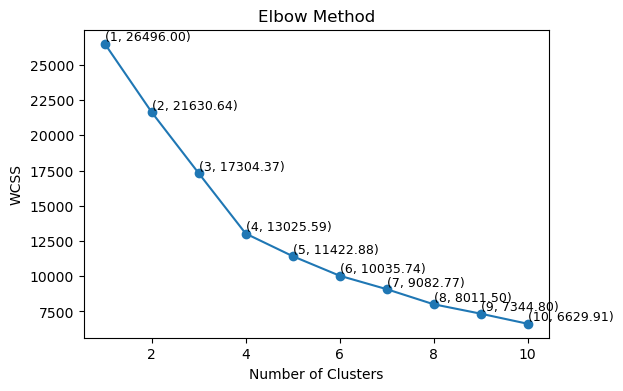

In [284]:
#1) Clustering 1 
 
# X_scaled features First 
from sklearn.preprocessing import StandardScaler
#new cluster_X
cluster_X = df[['Sales', 'Quantity', 'Discount', 'Unit Price', 'Region']].copy()

#CONVERT sales and unit price to log REDUCE SKEW 
cluster_X['Sales'] = np.log1p(cluster_X['Sales'])
cluster_X['Unit Price'] = np.log1p(cluster_X['Unit Price'])

#one-hot encode Region
cluster_X = pd.get_dummies(
    cluster_X,
    columns=['Region'],
    drop_first=False
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_X)

#A) Elbow Method (find best # of clusters)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []   #empty list of within cluster SS

for k in range(1,11):   #use k-values of 1 TILL 10
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10        #num of times k-means runs with diff centroid seeds
    )
    #fit model
    kmeans.fit(X_scaled)
    #append list 
    wcss.append(kmeans.inertia_)    #.inertia_ FINDS WCSS

#B) plot num of clusters vs. WCSS 
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

#Loop only to place the text labels
for i, j in zip(range(1,11), wcss):
    plt.text(i, j, f'({i}, {j:.2f})', ha='left', va='bottom', fontsize=9)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

- elbow around 4 or 5 here

In [285]:
#assign clusters to each row with new column 
profitdf['Cluster'] = kmeans.fit_predict(X_scaled)

#analyze clusters
profitdf.groupby('Cluster').mean(numeric_only=True)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Unit Price,profitable,Bestmodel_Cluster,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5394.502304,35696.059908,529.325177,3.940092,0.120737,34.025342,140.063256,0.774194,1.976959,-0.055300
1,5173.394737,92359.921053,23.681632,3.068826,0.065182,7.495912,8.665356,0.971660,1.000000,0.000000
2,4784.467961,16703.260194,33.557499,3.464078,0.084854,10.057624,10.812326,0.961165,1.023301,-0.013592
3,4955.050279,63658.670391,30.266902,3.536313,0.110056,8.140263,9.759662,0.938547,1.005587,-0.008380
4,4841.701068,63393.035587,470.032325,3.715302,0.156299,39.096916,136.308009,0.686833,1.978648,-0.078292
5,5424.023256,34979.202658,26.718585,3.521595,0.180399,4.868467,9.087482,0.847176,0.883721,0.073090
6,5130.127854,61489.867580,22.860589,3.776256,0.731507,-33.417578,6.369233,0.000000,0.000000,0.630137
7,5025.443627,92035.928922,410.099194,3.147059,0.116176,70.150106,132.442678,0.860294,1.884804,-0.041667
8,5141.614525,89288.072626,420.212494,8.318436,0.118994,71.378809,50.161763,0.882682,1.547486,-0.111732


- analysis think

In [286]:
#EACH CLUSTER vs. Region
pd.crosstab(profitdf['Cluster'], profitdf['Region'])

Region,Central,East,South,West
Cluster,,,,
0,0,0,217,0
1,0,0,0,494
2,0,515,0,0
3,358,0,0,0
4,281,0,0,0
5,0,0,301,0
6,137,60,0,22
7,0,0,0,408
8,2,6,0,171


In [287]:
#EACH CLUSTER vs. Category
pd.crosstab(profitdf['Cluster'], profitdf['Category'])

Category,Furniture,Office Supplies,Technology
Cluster,,,
0,70,85,62
1,65,386,43
2,79,372,64
3,16,299,43
4,97,99,85
5,39,227,35
6,34,184,1
7,127,150,131
8,43,95,41


In [288]:
#2) Silhouette Score      
from sklearn.metrics import silhouette_score

scores_list = [] #empty list

#loop for each k
for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0
    )
    #for each sample, LABEL in a cluster
    labels = kmeans.fit_predict(X_scaled)       #fit and predict in 1 step
    scores_list.append(silhouette_score(X_scaled, labels))

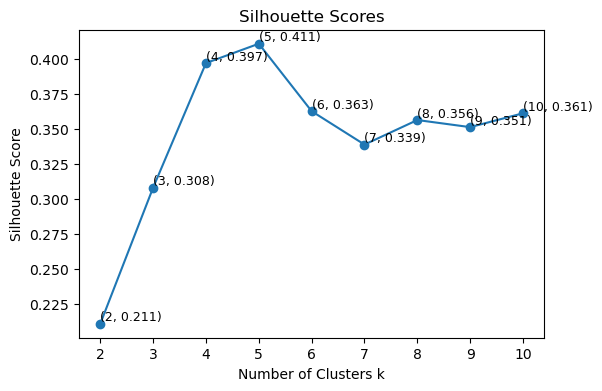

In [289]:
#plot
plt.figure(figsize=(6,4))
plt.plot(range(2,11),scores_list, marker='o')

#Loop only to place the text labels
for i, j in zip(range(2,11), scores_list):
    plt.text(i, j, f'({i}, {j:.3f})', ha='left', va='bottom', fontsize=9)

plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters k')
plt.ylabel('Silhouette Score')
plt.show()

- analysis NOW AFTER LOG SCALING sales and unit price, better silhouette score plot, instead of 2 clusters now 3 or 4

In [ ]:
#3) Best clustering K-means Model       USE THIS FIGURE!
kmeans = KMeans(
    n_clusters=3,
    random_state=0,
    n_init=10
)
#NEW FEATURE - assigns best model cluster label to each row
profitdf['Bestmodel_Cluster'] = kmeans.fit_predict(X_scaled)  

#analyze cluster
clustersummary = (
    profitdf.drop(columns = ['Row ID', 'Postal Code'])
    .groupby('Bestmodel_Cluster').mean(numeric_only=True)
)

clustersummary 

,Sales,Quantity,Discount,Profit,Unit Price,profitable,Cluster,DBSCAN_Cluster
Bestmodel_Cluster,,,,,,,,
0,231.360374,3.703583,0.147774,36.080957,61.858952,0.801303,4.883822,0.014115
1,231.267342,3.834470,0.121327,32.645917,62.113112,0.871048,3.939864,-0.002480
2,189.072144,3.701799,0.239614,9.705455,55.088722,0.681234,3.902314,0.046272


chat report analysis
- NOTE USED cluster_X to train kmeans, but HERE using ORIGINAL profitdf with NOT LOG SCALED values and assigning cluster = easier interpretation of table values


three CLUSTERS -> 0 = high discount, unprofitable, small orders
- 1 = highly profitable, least avg discount small orders
= 2 = most profit dollars, low discount, very large orders (avg $511 sales, avg unit $137)

Although both the three- and four-cluster solutions produced similar silhouette scores, the three-cluster solution was selected because it provided more interpretable and distinct customer segments. The four-cluster solution primarily subdivided an existing profitable segment without adding substantial new business insight (4th cluster split the 511 sales into 518 and 245 values)

In [291]:
#analyze each cluster vs. profitable
pd.crosstab(profitdf['Bestmodel_Cluster'], profitdf['profitable'])

profitable,0,1
Bestmodel_Cluster,,
0,183,738
1,208,1405
2,248,530


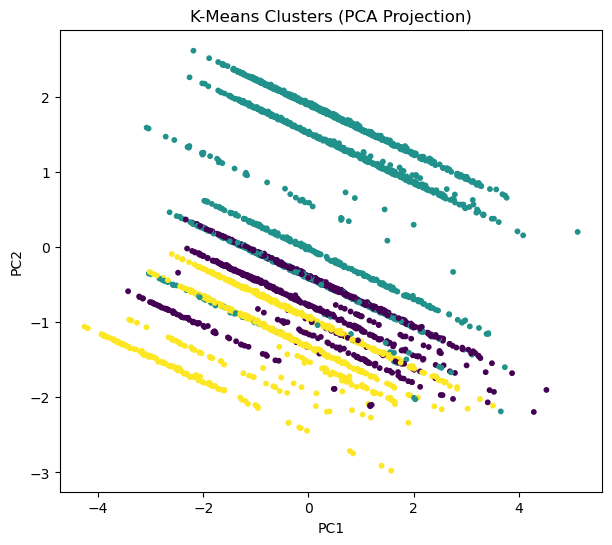

In [292]:
#4) PCA for Clustering
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

#scale features
X_pca = pca.fit_transform(X_scaled) #array only 2 components 

#Plot pca
plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],     #all rows, PC 1
    X_pca[:,1],     #all rows, PC 2
    c=profitdf['Bestmodel_Cluster'],  #color values 
    cmap='viridis',
    s=10    #marker size
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA Projection)')
plt.show()


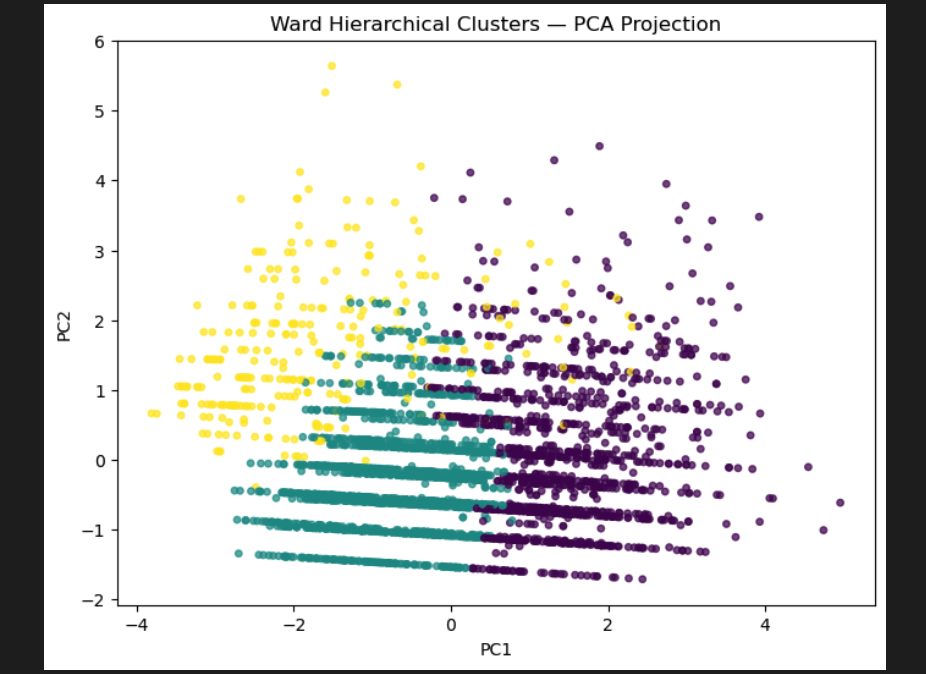

- separated pretty well along PC1, all 3 stretch long into PC2

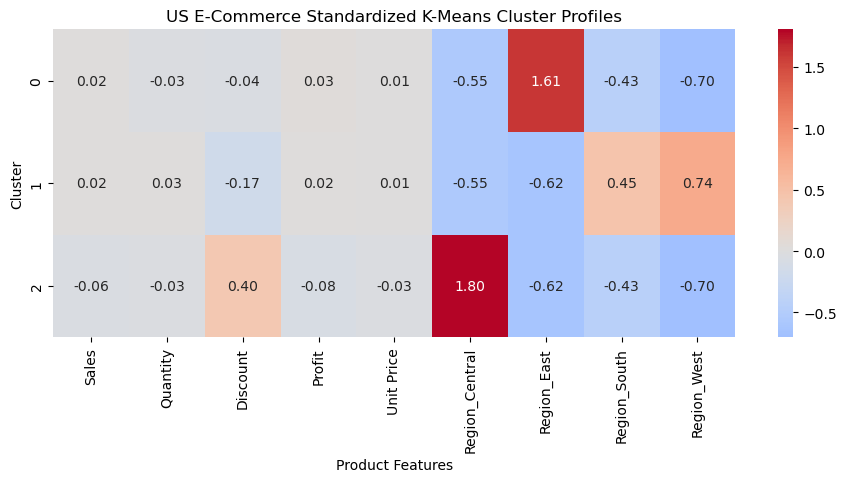

In [295]:
#CLUSTER PROFILE HEATMAP

from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#create copy of original features
cluster_heatmap = profitdf[
    ['Sales',
     'Quantity',
     'Discount',
     'Profit',
     'Unit Price',
     'Region',
     'Bestmodel_Cluster']
].copy()

#convert Region into dummy variables
cluster_heatmap = pd.get_dummies(
    cluster_heatmap,
    columns=['Region'],
    drop_first=False,
    dtype=int
)

#features to include in heatmap
cluster_features = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'Unit Price',
    'Region_Central',
    'Region_East',
    'Region_South',
    'Region_West'
]

#standardize features so different units can be compared
scaler = StandardScaler()

cluster_heatmap[cluster_features] = scaler.fit_transform(
    cluster_heatmap[cluster_features]
)

#find average standardized value for each cluster
cluster_profile = (
    cluster_heatmap
    .groupby('Bestmodel_Cluster')[cluster_features]
    .mean()
)

#plot heatmap
plt.figure(figsize=(11,4))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.xlabel("Product Features")
plt.ylabel("Cluster")
plt.title("US E-Commerce Standardized K-Means Cluster Profiles")

plt.show()

cluster 0 = MUCH HIGHER than average discounts, and slightly lower than average sales, profit, unit price (makes sense the essentials)

## Week 11 - Clustering 2
- include DBSCAN, HAC, linkage methods, dendrograms


In [272]:
#Choose best epsilon 
#model
dbscan = DBSCAN(
    eps=0.5,     #epsilon default min distance to be considered neighbor 
    min_samples=10
)
for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)

    print(
        f"eps={eps}:",
        pd.Series(labels).value_counts().sort_index().to_dict()
    )

eps=0.3: {-1: 689, 0: 142, 1: 357, 2: 143, 3: 304, 4: 302, 5: 151, 6: 65, 7: 352, 8: 69, 9: 213, 10: 121, 11: 20, 12: 23, 13: 189, 14: 25, 15: 46, 16: 22, 17: 26, 18: 15, 19: 10, 20: 10, 21: 11, 22: 7}
eps=0.5: {-1: 209, 0: 2910, 1: 163, 2: 11, 3: 7, 4: 12}
eps=0.7: {-1: 68, 0: 3244}
eps=1.0: {-1: 23, 0: 3289}
eps=1.5: {-1: 2, 0: 3310}


In [273]:
#1) DBSCAN          useful for non-linear clusters
from sklearn.cluster import DBSCAN

#model
dbscan = DBSCAN(
    eps=0.5,     #epsilon default min distance to be considered neighbor 
    min_samples=10
)

#predictions
dbscan_pred = dbscan.fit_predict(X_scaled)
dbscan_pred

#new feature that labels each row in a cluster
profitdf['DBSCAN_Cluster'] = dbscan_pred
profitdf['DBSCAN_Cluster'].sort_values(ascending=False)

777     4
209     4
1965    4
326     4
2743    4
       ..
3133   -1
2302   -1
182    -1
1312   -1
1001   -1
Name: DBSCAN_Cluster, Length: 3312, dtype: int64

In [204]:
# 1b) Num of Clusters and Noise Points
n_noise = list(dbscan_pred).count(-1)
n_clusters = profitdf['DBSCAN_Cluster'].nunique() - (1 if -1 in dbscan_pred else 0)    #since -1 present, subtract 1 from total clusters

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 5
Number of noise points: 209


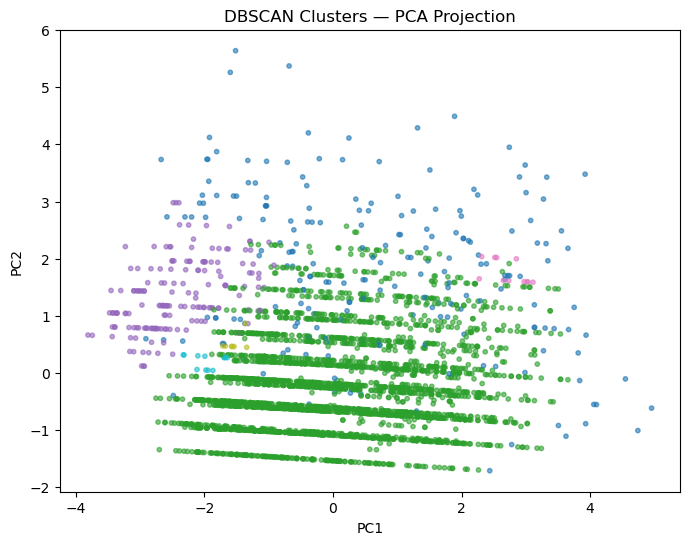

In [207]:
#1C) DBSCAN PCA plot
pca = PCA(n_components=2)
#scale
X_pca = pca.fit_transform(X_scaled)

#Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_pred,  #color values
    cmap = 'tab10',
    s=10,   #size of points
    alpha = 0.6
)

plt.title('DBSCAN Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [212]:
#1D) Test different DBSCAN parameters       (3min runtime)          USE THIS FIGURE MAYBE

dbscan_results = []

#parameters list
eps_values = [0.2,0.3,0.4,0.5,0.6,0.7]
min_sample_values = [5,10,20,50]

#Double for-loop 
for eps in eps_values:
    for min_samples in min_sample_values:
        #create dbscan
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
        )
        #predict cluster labels
        labels = dbscan.fit_predict(X_scaled)

        #variables for how many noise and clusters
        n_noise = list(labels).count(-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)    #since -1 present, subtract 1 from total clusters
        non_noise = labels != -1 

        #calculate silhouette score if viable
        if n_clusters >=2 and non_noise.sum() > n_clusters:     #cannot have more clusters than non_noise data points
            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise],
            )
        else:
            score = None
        
        #append results to list FOR EACH PARAMETER trial
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'noise_points': n_noise,
            'silhouette_score': score
        })

#convert results to df
dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.sort_values('silhouette_score', ascending=False)



,eps,min_samples,clusters,noise_points,silhouette_score
3,0.2,50,4,2994,0.645140
23,0.7,50,2,367,0.474077
18,0.6,20,2,231,0.456556
22,0.7,20,2,133,0.442106
7,0.3,50,6,2538,0.414702
17,0.6,10,3,104,0.407606
16,0.6,5,2,64,0.330524
12,0.5,5,5,102,0.314390
20,0.7,5,2,45,0.314374
13,0.5,10,5,209,0.165316


- 90% data noise for top result even though 0.645 SIL S, choose 2nd result instead

In [215]:
pd.crosstab(profitdf['DBSCAN_Cluster'], profitdf['Region'])

Region,Central,East,South,West
DBSCAN_Cluster,,,,
-1,77,56,24,52
0,614,812,465,1019
1,76,47,26,14
2,0,1,2,8
3,7,0,0,0
4,4,5,1,2


In [216]:
pd.crosstab(profitdf['DBSCAN_Cluster'], profitdf['Category'])

Category,Furniture,Office Supplies,Technology
DBSCAN_Cluster,,,
-1,63,97,49
0,595,1745,570
1,13,150,0
2,4,3,4
3,7,0,0
4,4,7,1


In [ ]:
#2) Hierarchical Agglomerative Clustering (HAC)
X_hac = X_scaled #3312 rows

In [220]:
#2B) Compare Linkage Methods
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#list of methods
linkage_methods = [
    'ward',
    'complete',
    'average',
    'single'
]

hac_results = []    #empty list

#loop over each method
for method in linkage_methods:
    #CREATE HAC MODEL HERE
    hac = AgglomerativeClustering(
        n_clusters=3,
        linkage=method,
        metric='euclidean'
    )

    #find predictions
    labels = hac.fit_predict(X_hac)

    score = silhouette_score(X_hac, labels) #actual, predicted

    #append to list
    hac_results.append({
        'Linkage': method,
        'Silhouette Score': score
    })

#show results
hac_results = pd.DataFrame(hac_results)
hac_results.sort_values('Silhouette Score', ascending=False)



,Linkage,Silhouette Score
3,single,0.416483
2,average,0.367790
0,ward,0.355542
1,complete,0.284942


- here complete linkage did the worst, whereas amazon ward linkage did worst

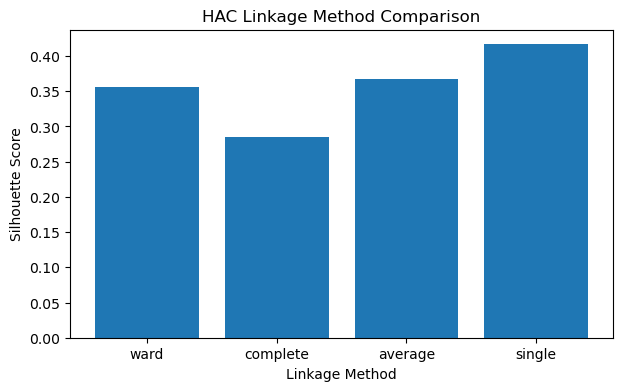

In [221]:
#2C) Plot linkage vs. sil score 
plt.figure(figsize=(7,4))

plt.bar(
    hac_results['Linkage'],
    hac_results['Silhouette Score']
)

plt.title('HAC Linkage Method Comparison')
plt.xlabel('Linkage Method')
plt.ylabel('Silhouette Score')

plt.show()

In [222]:
#FIND BEST amount of clusters
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 7):

    hac = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = hac.fit_predict(X_hac)

    results.append({
        'Clusters': k,
        'Silhouette': silhouette_score(X_hac, labels)
    })

pd.DataFrame(results) #use 3 clusters

,Clusters,Silhouette
0,2,0.313463
1,3,0.355542
2,4,0.325927
3,5,0.256661
4,6,0.254250


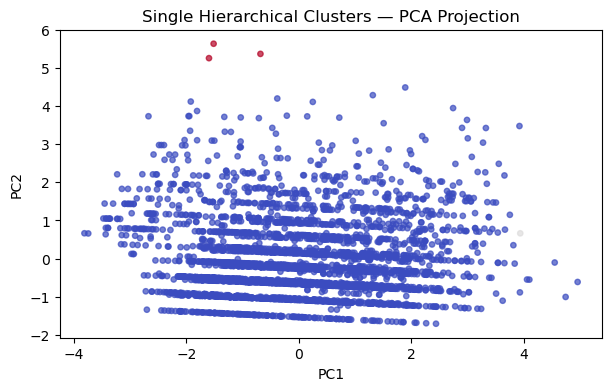

In [299]:
#2D) Fit FINAL HAC model using ward
# list = ['ward','single', 'complete', 'average'] REMEMBER others besides ward had bad PCA plots all one color

hac = AgglomerativeClustering(
    n_clusters=3,       
    linkage= 'single'    #ward most distinct clusters
)

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)

#2E) HAC PCA Plot
X_hac_pca = PCA(n_components=2).fit_transform(X_hac)

plt.figure(figsize=(7,4))

plt.scatter(
    X_hac_pca[:, 0],
    X_hac_pca[:, 1],
    c=best_hac_labels,
    cmap='coolwarm',
    s=15,
    alpha=0.7
)

plt.title(f'Single Hierarchical Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

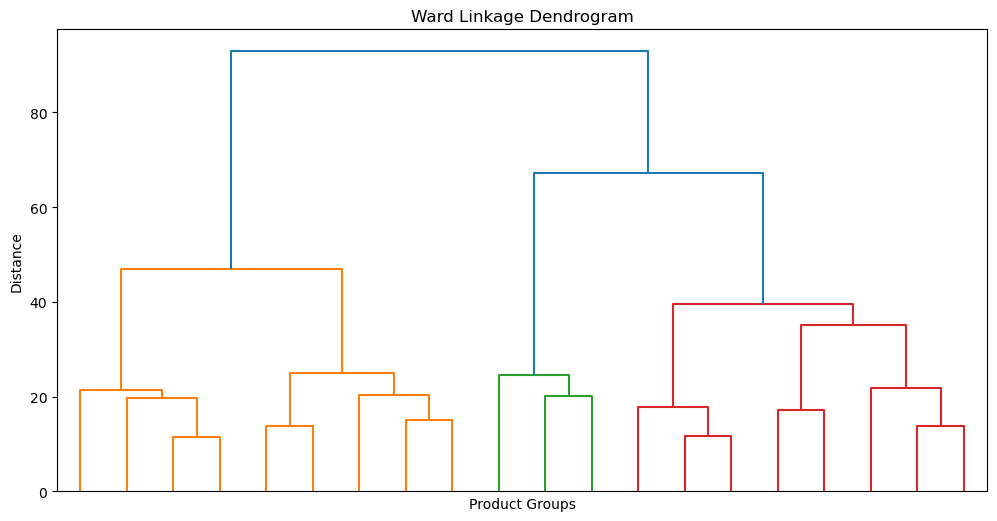

In [271]:
#3) DENDROGRAM
from scipy.cluster.hierarchy import linkage, dendrogram
X_dendrogram = X_scaled #3312 rows

#3B) Ward Dendrogram

#perform HAC first to get matrix
linkage_matrix = linkage(           #output 2D array with 4 columns (cluster1, cluster2, distance_method, size of cluster)
    X_dendrogram,
    method='ward',
    metric='euclidean'
)

plt.figure(figsize=(12,6))

#create dendrogram
dendrogram(
    linkage_matrix,     #encodes the hierarchical clustering
    truncate_mode='lastp',  #last p non-singleton clusters formed in the linkage are the only non-leaf nodes
    p=20,                    
    no_labels=True
)

plt.title('Ward Linkage Dendrogram')
plt.xlabel('Product Groups')
plt.ylabel('Distance')

plt.show()


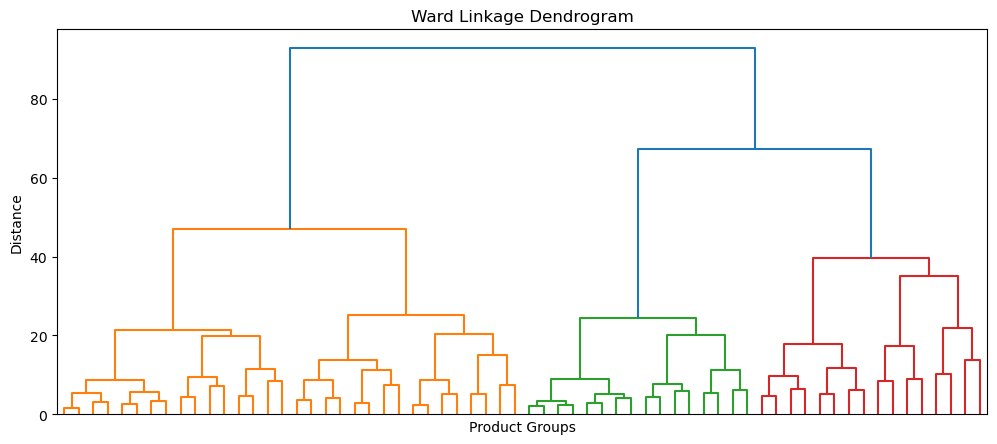

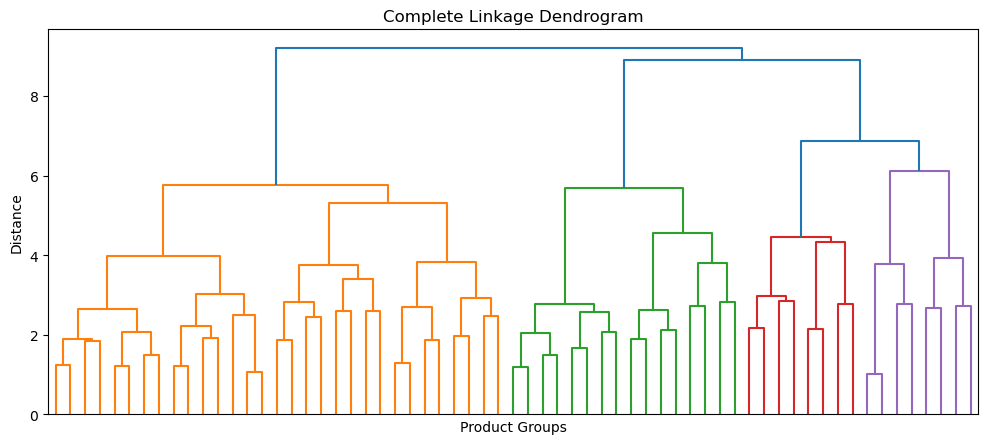

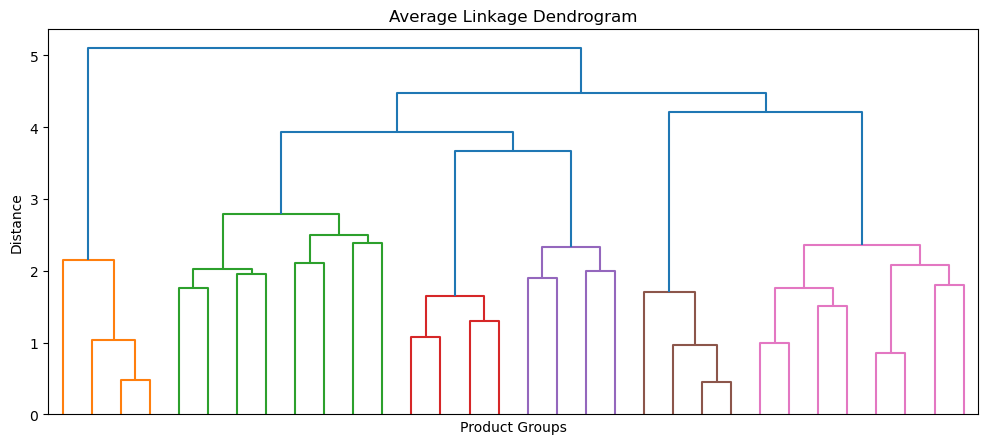

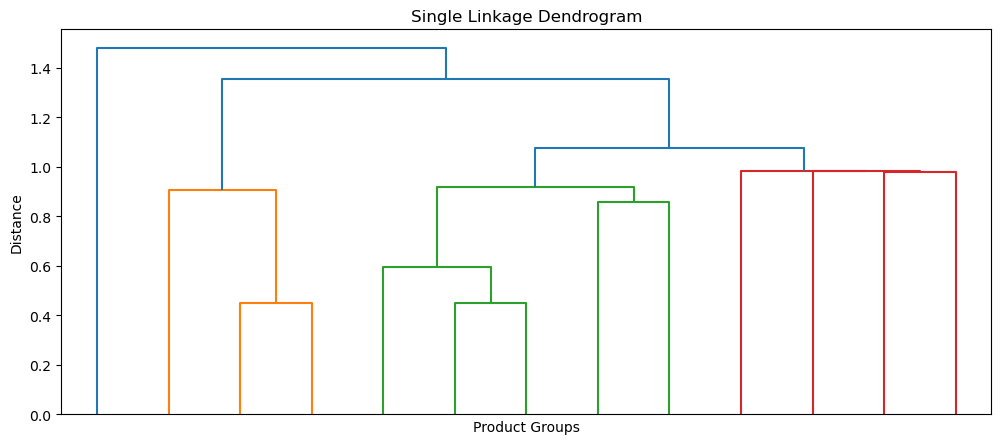

In [227]:
#3C) Compare dendrograms for each linkage method 

for method in ['ward', 'complete', 'average', 'single']:
    linkage_matrix = linkage(
        X_dendrogram,
        method=method,
        metric='euclidean'
    )

    plt.figure(figsize=(12,5))

    dendrogram(
        linkage_matrix,
        truncate_mode='level',
        p=5,
        no_labels=True
    )

    plt.title(f'{method.title()} Linkage Dendrogram')
    plt.xlabel('Product Groups')
    plt.ylabel('Distance')

    plt.show()

In [229]:
#view cluster sizes

#use best HAC model from above
hac = AgglomerativeClustering(
        n_clusters=3,       
        linkage= 'ward'    #ward most distinc clusters
    )

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)


# Create dataframe for sampled products
df_hac = profitdf.copy()

# Add cluster labels
df_hac['Ward_Cluster'] = best_hac_labels

df_hac['Ward_Cluster'].value_counts().sort_index()

Ward_Cluster
0    1280
1    1748
2     284
Name: count, dtype: int64

In [234]:
# Ward Cluster summary
ward_clustersummary = (
    df_hac
    .groupby('Ward_Cluster')[
        [
            'Sales',
            'Quantity',
            'Discount',
            'Profit',
            'Unit Price',
            'profitable'
        ]
    ]
    .mean()
    .round(2)
)

ward_clustersummary

,Sales,Quantity,Discount,Profit,Unit Price,profitable
Ward_Cluster,,,,,,
0,510.24,4.44,0.11,84.65,134.90,0.82
1,32.83,3.23,0.10,7.15,12.65,0.93
2,80.01,4.04,0.72,-96.50,18.43,0.00
